***Acerca del proyecto***

El presente proyecto se trata acerca de un análisis de abandono de clientes, mejor conocido como "Customer Churn".

Este tiene como finalidad identificar a los clientes más propensos a dejar de utilizar los servicios de la institución, que en este caso se trata de una institución bancaria.

El set de datos proviene de https://www.kaggle.com/datasets/bhuviranga/customer-churn-data , el cual está conformado de las columnas credit_score, country, gender, age, tenure, balance, products_number, credit_card, active_member, estimated_salary y churn. Así como de 10,000 observaciones.

Se pretende resolver el antes mencionado problema con el apoyo de técnicas de  **Aprendizaje automático** , las cuales han demostrado tener un desempeño notable ante este tipo de casos.

Durante la etapa de **modelado** del proyecto se pretende utilizar técnicas de:

- Regresión logística

- Random Forest

- XGBoost

Posterior a la etapa de modelado y evaluación, se procederá a optimizar los parámetros del modelo que haya obtenido las mejores métricas para optimizar su desempeño y finalmente denominarlo como el modelo ganador.

***Descripción de variables***

**"customer_id":**

Esta variable indica el número de identificación único asignado a cada cliente dentro del sistema del banco. No tiene relación con el comportamiento financiero, sino que sirve para distinguir un registro de otro.

**"credit_score":**

Esta variable indica la calificación crediticia del cliente. Es un valor numérico que refleja la solvencia y el historial de cumplimiento financiero; generalmente, a mayor puntaje, el cliente se considera de menor riesgo para la institución.

**"country":**

Esta variable indica el país donde reside el cliente y donde tiene registrada su cuenta (en este dataset: Francia, Alemania o España). Es un dato categórico que ayuda a identificar diferencias culturales o económicas por región.

**"gender":**

Esta variable indica el género biológico del cliente (Masculino o Femenino). Se utiliza para realizar análisis demográficos y entender si existen patrones de abandono diferenciados por sexo.

**"age":**

Esta variable indica la edad cronológica del cliente en años. Es una de las variables demográficas más importantes, ya que las necesidades bancarias y la lealtad suelen cambiar drásticamente según la etapa de vida.

**"tenure":**

Esta variable indica la antigüedad del cliente con el banco, representada en número de años. Ayuda a diferenciar entre clientes nuevos (que podrían estar en periodo de prueba) y clientes leales de largo plazo.

**"balance":**

Esta variable indica el saldo total que el cliente mantiene en su cuenta bancaria al momento del corte. Un saldo alto suele indicar una mayor vinculación, mientras que saldos en cero pueden preceder a un abandono.

**"products_number":**

Esta variable indica la cantidad total de productos financieros que el cliente tiene contratados con el banco (por ejemplo: cuenta de ahorros, préstamos, inversiones, etc.).

**"credit_card":**

Esta variable indica si el cliente posee o no una tarjeta de crédito con la institución. Se presenta de forma binaria, donde 1 significa que sí cuenta con ella y 0 que no.

**"active_member":**

Esta variable indica si el cliente interactúa frecuentemente con el banco o si su cuenta ha tenido movimiento reciente. Es una métrica de compromiso (engagement) donde 1 representa un miembro activo.

**"estimated_salary":**

Esta variable indica el ingreso anual aproximado del cliente. Al ser una estimación, sirve para perfilar el nivel socioeconómico y la capacidad financiera del individuo.

**"churn":**

Esta variable indica si el cliente ha cancelado su relación con el banco (1) o si permanece como cliente activo (0). Es la variable objetivo o "target" que nuestro modelo intentará predecir.

***Fase 1: Carga de datos***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# instanciando data set en objeto df_bank
df_bank = pd.read_excel('/content/drive/MyDrive/Materias ISEC/Analítica de datos/Resultados .xlsx')

# consultando muestra para verificar carga correcta
df_bank.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# para conocer las dimensiones del dataset
df_bank.shape

(10000, 12)

***Fase 2. Limpieza Inicial (Preprocesamiento)***

In [5]:
# para verificar tipos de datos (Data Casting)
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [6]:
# para verificar completitud
df_bank.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [7]:
# para verificar duplicados
df_bank.duplicated().sum()

np.int64(0)

In [8]:
#para ver las generalidades y estadísticas básicas del data set
df_bank.describe(include="all")

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


In [9]:
# de manera general, se puede observar que la única columna que no aporta valor para el proyecto es customer_id
# En este caso se desea conocer las generalidades de clientes propensos a abandonar, no alguno en específico.
# Por lo que se ha tomado la decisión de eliminar de manera temprana dicha variable.
# por "buenas prácticas" se procederá a generar una copia del dataset original , sobre el que se realizarán las
# modificaciones pertinentes a lo largo del proyecto.

df_bank_copy = df_bank.copy() # para crear la copia
df_bank_copy.drop(columns=['customer_id'], inplace=True) # para eliminar la columna
df_bank_copy.head() # para verificar cambios


,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# para conocer las nuevas dimensiones
df_bank_copy.shape

(10000, 11)

***Fase 3. Análisis Exploratorio de Datos***

In [11]:
# primero se desea conocer la variable objetivo, para posteriormente analizar las variables predictoras

print('Conteo por clase')
print(df_bank_copy['churn'].value_counts())

print('\nPorcentaje por clase')
print(df_bank_copy['churn'].value_counts() / df_bank_copy['churn'].shape[0])

Conteo por clase
churn
0    7963
1    2037
Name: count, dtype: int64

Porcentaje por clase
churn
0    0.7963
1    0.2037
Name: count, dtype: float64


**Observaciones variable target**

Como se puede apreciar, la clase que se pretende predecir es aproximadamente $1/5$ del total del obervaciones en el data set, por lo que en etapas futuras será necesario llevar a cabo un tratamiento sobre dicha variable para intentar balancearla y el modelo no asigne un mayor peso a la clase mayoritaria.

-------------------------------------------

**Distribución y frecuencia de variables**

 Es de suma importancia conocer cuál es la forma y frecuencias que tienen cada una de las variable, ya que será una guía de como deberán ser tratadas para la etapa de la ingeniería de características previa al modelado.

 Antes de llevar a cabo dicho análisis es necesario clasificar las variables de acuerdo a su tipo (**Taxonomía de variables**):

 - Numéricas

 - Ordinales

 - Nominales

 - Binarias

In [12]:
# para poder clasificarlas se necesita de acuerdo a su naturaleza se realizará un análisis general
resumen_general = pd.DataFrame({
  'Tipo de dato': df_bank_copy.dtypes,
  'Valores únicos': df_bank_copy.nunique(),
  'Ejemplos': [df_bank_copy[col].unique()[:6] for col in df_bank_copy.columns] # muestra los primeros 5 valores encontrados de cada columna (en caso de que haya más de 5)
})

# Visualizando resumen
resumen_general

,Tipo de dato,Valores únicos,Ejemplos
credit_score,int64,460,"[619, 608, 502, 699, 850, 645]"
country,object,3,"[France, Spain, Germany]"
gender,object,2,"[Female, Male]"
age,int64,70,"[42, 41, 39, 43, 44, 50]"
tenure,int64,11,"[2, 1, 8, 7, 4, 6]"
balance,float64,6382,"[0.0, 83807.86, 159660.8, 125510.82, 113755.78..."
products_number,int64,4,"[1, 3, 2, 4]"
credit_card,int64,2,"[1, 0]"
active_member,int64,2,"[1, 0]"
estimated_salary,float64,9999,"[101348.88, 112542.58, 113931.57, 93826.63, 79..."


In [13]:
# De acuerdo con la muestra anterior:

variables_numéricas = ['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary']
variables_nominales = ['country', 'gender']
variables_binarias = ['credit_card', 'active_member', 'churn']

# Nota: para este caso específico no se identificaron variables con un perfil de categorías ordinales.

# Anteriormente se tenía un set de datos con 11 variables. Se vuelve a imprimir la dimensión sumando
# la cantidad de variable spor grupo y de esta manera vertificar que no se deja fuera a ninguna.

total_de_variables = len(variables_numéricas) + len(variables_nominales) + len(variables_binarias)
print(f'La cantidad total de variables es: {total_de_variables} ')

La cantidad total de variables es: 11 


**Análisis de Univariado Variables Numéricas**



In [14]:
# Estadísticas descriptivas para variables numéricas

estadisticas_basicas = df_bank_copy[variables_numéricas].describe().T
asimetria = df_bank_copy[variables_numéricas].skew()
curtosis = df_bank_copy[variables_numéricas].kurtosis()

estadisticas_variables_numericas = pd.concat([estadisticas_basicas,asimetria,curtosis], axis=1)
estadisticas_variables_numericas.columns = list(estadisticas_basicas.columns) + ['asimetria', 'curtosis']
estadisticas_variables_numericas

,count,mean,std,min,25%,50%,75%,max,asimetria,curtosis
credit_score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00,-0.071607,-0.425726
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00,1.011320,1.395347
tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00,0.010991,-1.165225
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09,-0.141109,-1.489412
products_number,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00,0.745568,0.582981
estimated_salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48,0.002085,-1.181518


**Observaciones acerca de estadísticas descriptivas**

**1. Variables con Outliers Confirmados**

**age:** El valor máximo es 92 años, mientras que el 75% de los clientes tiene menos de 44. Se tiene una población mayor que se sale del estándar.

**credit_score:** El valor mínimo es 350. Considerando que la media es 650, un 350 es un puntaje extremadamente bajo que podría indicar clientes en situaciones financieras críticas.

**2. El fenómeno del balance**

Es necesario notar que el valor del percentil 25% (25%) es 0.00.

**Observación:** Esto significa que al menos una cuarta parte de toda la base de datos tiene saldo cero. Esto no es un error de datos, es un comportamiento de negocio que segmenta a clientes en "activos con ahorro" y "usuarios de cuenta básica/vacía".

**3. Distribución de estimated_salary**

La media cercana a $100,090$ y la mediana o 50% cercana a $100,193$ están casi idénticas.

**Observación:** Se nota que los salarios están distribuidos de forma muy uniforme. No hay un sesgo hacia "gente rica" o "gente pobre"; el banco tiene una muestra muy equilibrada de ingresos.

**4. Estabilidad en tenure y products_number**

**tenure:** La media es 5 años. El banco tiene clientes con cierta antigüedad, no es una cartera "nueva".

**products_number:** El 75% de los clientes tiene 2 productos o menos. Aquellos con 3 o 4 son la excepción, y será importante ver en el análisis bivariado si ese exceso de productos correlaciona con el abandono.

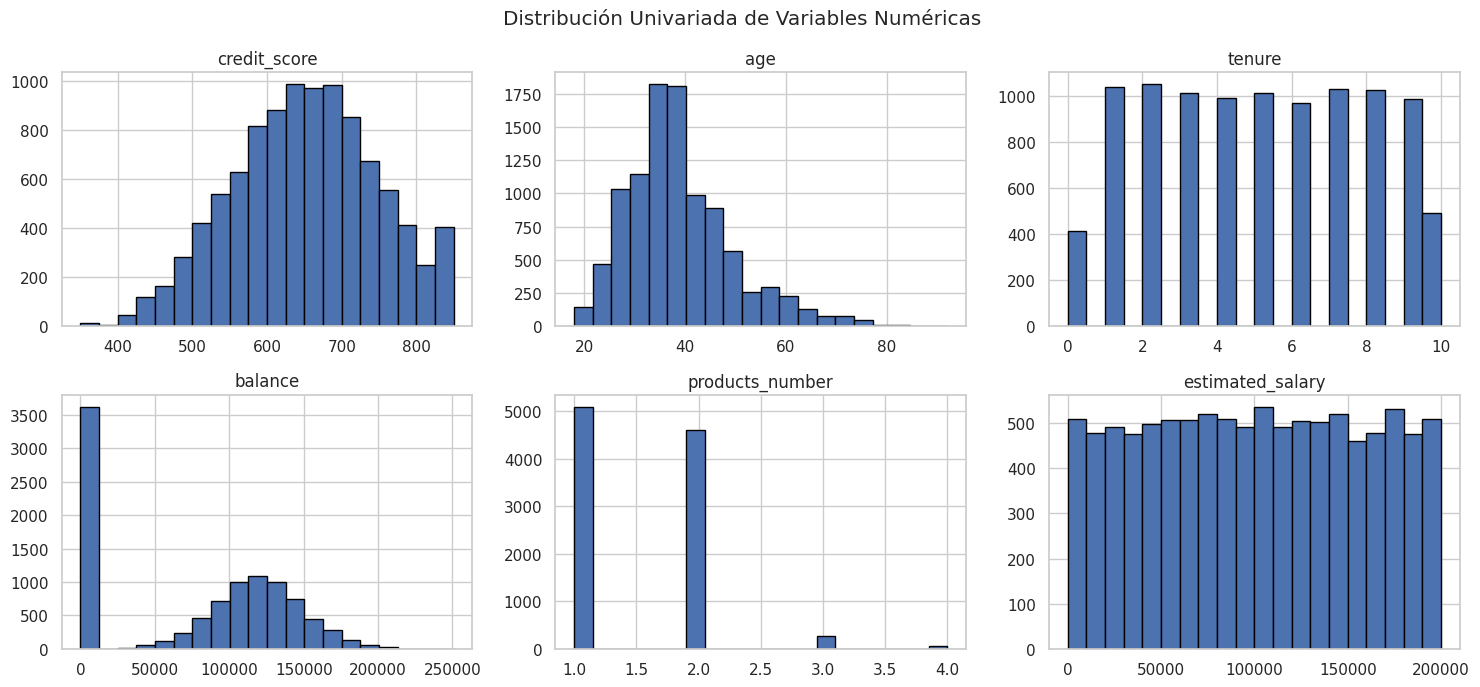

In [15]:
# Graficando variables numéricas

sns.set_theme(style='whitegrid')
df_bank_copy[variables_numéricas].hist(
    figsize=(15,7),
    bins=20,
    layout=(2,3),
    edgecolor='black'
)
plt.suptitle("Distribución Univariada de Variables Numéricas")
plt.tight_layout()
plt.show()


**Observaciones para Distribución Univariada de Variables Numéricas**

**1. La bimodalidad de "balance"**

Esta es la gráfica más curiosa y reveladora a la vez. Permite ver que no es una distribución normal; es bimodal.

Hay un grupo masivo concentrado en el 0 y el resto de los clientes se distribuye normalmente con una media cercana a los 125,000.

**Estrategia:** En la Fase de Ingeniería de Características, quizá valdría la pena crear una variable binaria: tiene_balance_cero (Sí/No), ya que el modelo podría encontrar mucha señal ahí. Sin embargo, es algo que se decidirá más adelante.

**2. El sesgo a la derecha en "age"**

La curva tiene una cola larga hacia la derecha. La mayoría de los clientes son jóvenes-adultos (30-45 años).

**Insight:** Los clientes que superan los 60 años son pocos, pero como se observó en la tabla de estadísticas, llegan hasta los 92. Habrá que vigilar si este pequeño grupo senior es más o menos propenso al churn.

**3. Distribución Uniforme en estimated_salary y tenure**

**Salario:** Es casi una línea plana, una distribución uniforme. Esto significa que el banco ha captado clientes de todos los niveles adquisitivos por igual. No hay un "perfil salarial" típico.

**Antigüedad (Tenure):** Se ve muy estable entre los 1 y 9 años, con ligeras caídas en los extremos (0 y 10), sin embargo, es una distribución muy parecida a la del salario, no se tiene una antigüedad "pico" de clientes.

**4. La anomalía en credit_score**

Aunque parece una distribución normal perfecta, hay que poner atención en la barra del extremo derecho (valores cercanos a 850). Hay un "pico" artificial de clientes con puntaje máximo.

**Insight:** Esto suele ocurrir cuando el sistema "topa" a todos los clientes excelentes en una misma calificación máxima, por lo que si dicha métrica llegara a un valor más alto, quizá a 950, probablemente la distribución tendería a la normalidad.

**5. Concentración en products_number**

La gran mayoría tiene 1 o 2 productos. Los casos de 3 y 4 son muy escasos (barras pequeñas).

**Alerta:** Si el Churn es alto en los que tienen 3 o 4 productos, tendremos un problema de "pocos datos" para esa minoría, pero un insight de negocio muy importante.

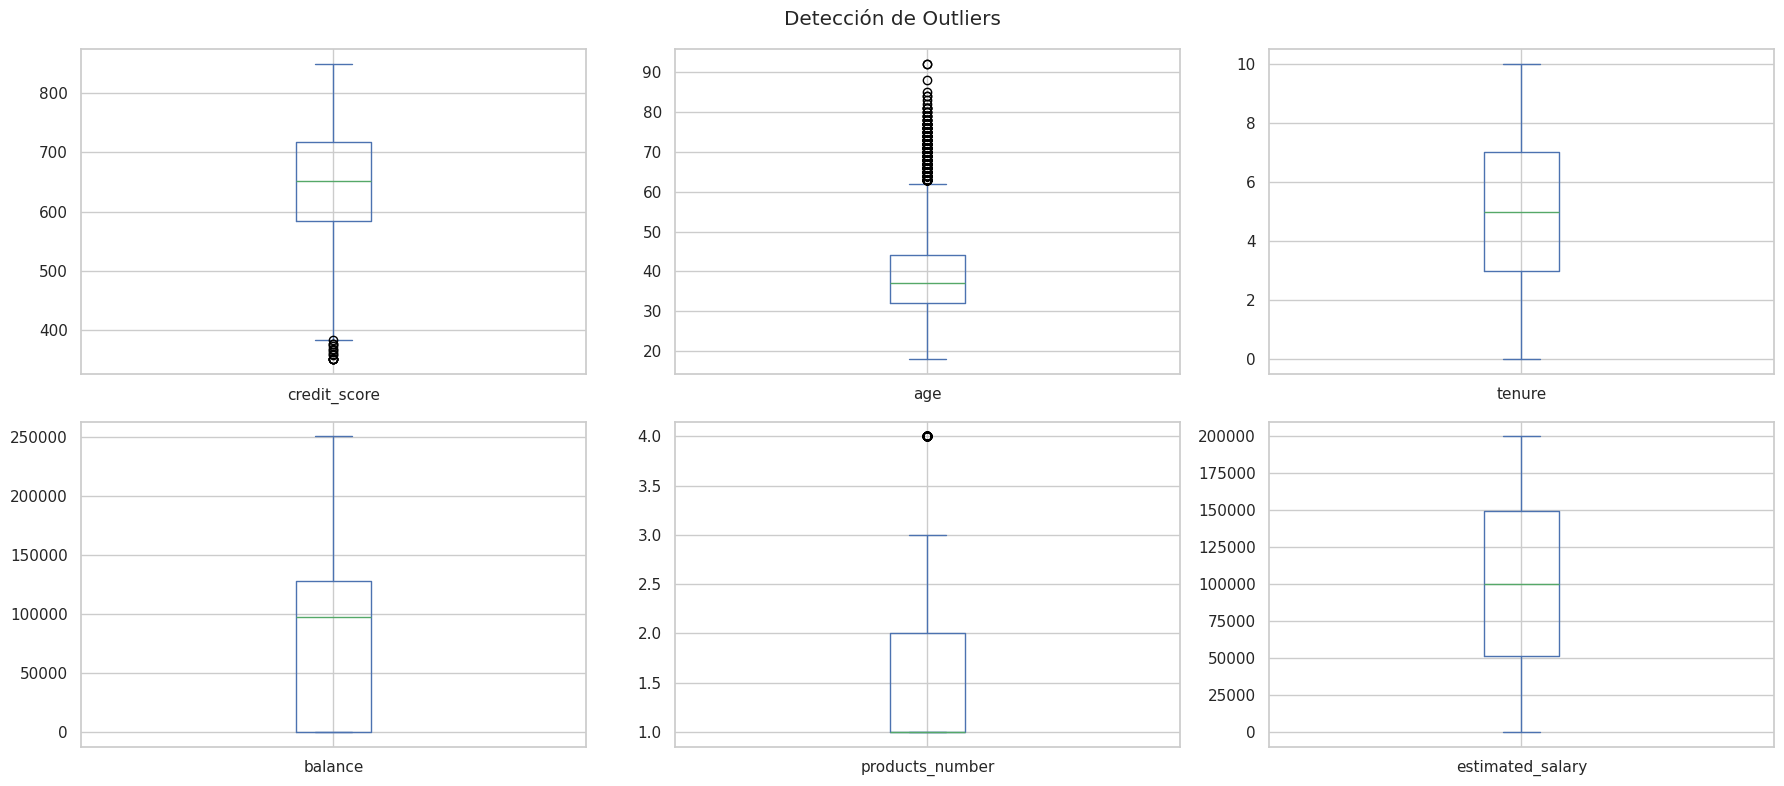

In [16]:
# Para conocer  valores atípicos

df_bank_copy[variables_numéricas].plot(
    kind='box',
    subplots=True,
    layout=(2,3),
    figsize=(18,8),
    sharex=False,
    sharey=False,
    title="Detección de Outliers"
)

plt.tight_layout()
plt.show()

**Observaciones para valores atípicos de variables numéricas**

**1. Edad (age): El punto de mayor atención**

Como se anticipó de acuerdo con la tabla estadística, es la variable con más valores atípicos.

**Observación:** Los puntos por arriba del bigote superior indican que cualquier cliente por encima de los 62 años aproximadamente es considerado un outlier estadístico en este dataset.

**Decisión técnica:** No eliminarlos. En banca, los clientes senior suelen tener comportamientos de inversión o ahorro muy distintos (pueden ser los más leales o los que retiran todo al jubilarse). Es mejor mantenerlos para que el modelo aprenda de ellos. Sin embargo, se realizarán tratamientos para cuidar la el desbalance de la distribución y de esta manera el modelo no le otorgue más "importancia" a valores más altos.

**2. Puntaje de Crédito (credit_score):**

**Riesgo extremo.** Aquí los outliers están por debajo del bigote inferior.Hay un grupo pequeño de clientes con puntajes por debajo de 400.

**Insight:** Estos son clientes en situación de riesgo crediticio. Será interesante ver si estos "outliers" tienen una tasa de abandono más alta por falta de acceso a productos financieros.

**3. Variables "Limpias" (Sin Outliers): tenure, balance y estimated_salary**

No presentan ni un solo punto fuera de los bigotes.

Interpretación: Esto es optimo para modelos como la Regresión Logística, ya que no tendrá que lidiar con salarios o saldos atípicos que sesguen los coeficientes. Los datos están bien acotados.

**4. Número de Productos (products_number)**

Aquí se nota que el bigote superior llega hasta 3, y el 4 aparece como un punto aislado.

**Alerta:** Tener 4 productos es estadísticamente raro en este banco. Habrá que vigilar si esto es un error de captura o un perfil de cliente muy específico.

--------------------------------------------------

**Análisis Univariado de variables nominales**

--- Distribución de country ---
country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


--- Distribución de gender ---
gender
Male      5457
Female    4543
Name: count, dtype: int64
gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64




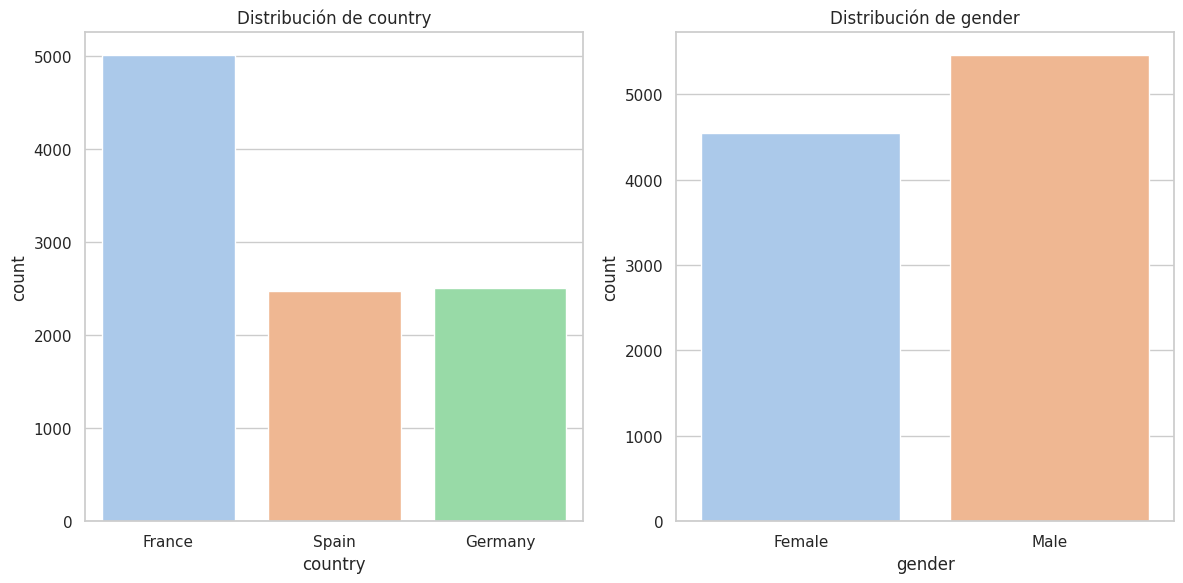

In [17]:
# para imprimir los valores numéricos y la distribución porcentual
for col in variables_nominales:
    print(f"--- Distribución de {col} ---")
    print(df_bank_copy[col].value_counts())
    print(df_bank_copy[col].value_counts(normalize=True) * 100)
    print("\n")

# Para dibujar las figuras :
plt.figure(figsize=(12, 6))

for i, col in enumerate(variables_nominales):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df_bank_copy, x=col, palette='pastel', hue=col, legend=False)
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

**Observaciones para variables nominales**

**1. Sobre el País (country):**

**Concentración:** El banco tiene una dependencia muy fuerte del mercado francés. Con un 50.14%, prácticamente uno de cada dos clientes es de Francia.

**Distribución Secundaria:** Alemania (25.09%) y España (24.77%) están casi empatados en cantidad de clientes.

**Punto de atención:** Al tener grupos de tamaños tan distintos (Francia vs. los otros dos), se debe ser cuidadosos. Si el comportamiento en Francia es muy "estable", podría ocultar problemas en los mercados más pequeños si solo se miran promedios generales, por lo que será necesario explorar esta variable más adelante y ver como se distribuye contra el churn.

**2. Sobre el Género (gender):**

**Composición:** Hay una ligera predominancia de hombres (54.57%) frente a mujeres (45.43%).

**Equilibrio:** Aunque hay más hombres, una diferencia de alrededor de 9 puntos porcentuales no se considera un desbalance crítico. Los datos son lo suficientemente representativos para ambos grupos, lo que permitirá que el modelo aprenda patrones de comportamiento para ambos géneros sin sesgos mayores.

-------------------------------------------------------------

**Análisis univariado para bariables binarias**

--- Distribución de credit_card ---
credit_card
1    7055
0    2945
Name: count, dtype: int64
credit_card
1    70.55
0    29.45
Name: proportion, dtype: float64


--- Distribución de active_member ---
active_member
1    5151
0    4849
Name: count, dtype: int64
active_member
1    51.51
0    48.49
Name: proportion, dtype: float64


--- Distribución de churn ---
churn
0    7963
1    2037
Name: count, dtype: int64
churn
0    79.63
1    20.37
Name: proportion, dtype: float64




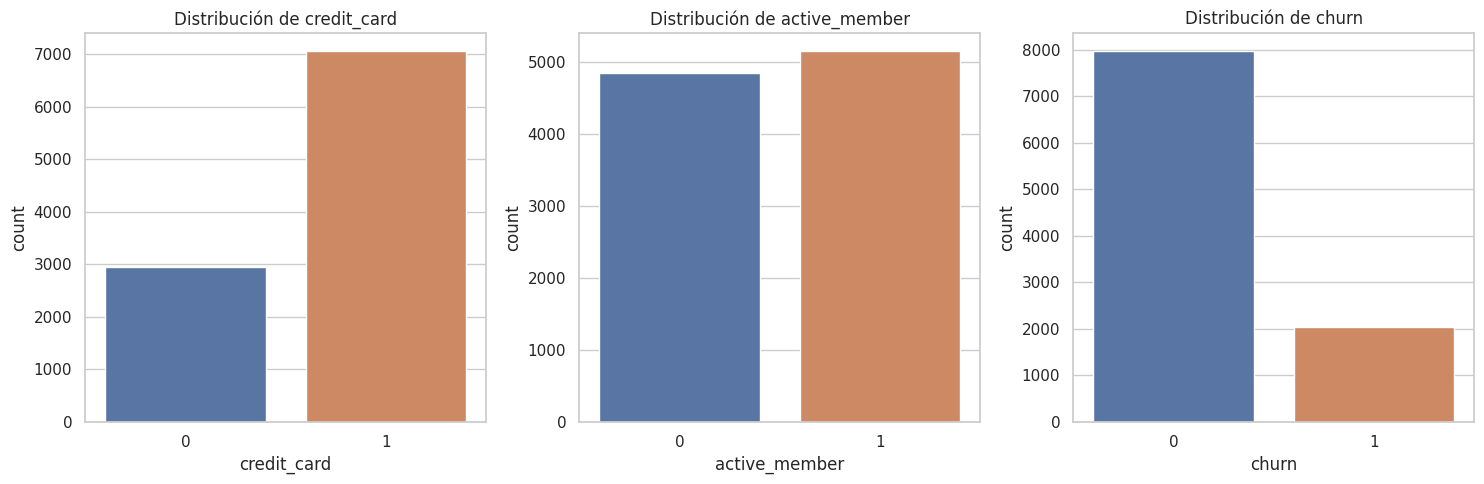

In [18]:
# Para imprimir valores numéricos y distribución porcentual
for col in variables_binarias:
    print(f"--- Distribución de {col} ---")
    print(df_bank_copy[col].value_counts())
    print(df_bank_copy[col].value_counts(normalize=True) * 100)
    print("\n")

# 2. Para dibujar las figuras
plt.figure(figsize=(15, 5))

for i, col in enumerate(variables_binarias):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df_bank_copy, x=col, hue=col, legend=False)
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

**Observaciones para variables binarias**

**1. Posesión de Tarjeta de Crédito (credit_card):**

Alta colocación: El 70.55% de los clientes tienen tarjeta de crédito.

Interpretación: La tarjeta de crédito es el producto estándar. Dado que la gran mayoría cuenta con una, esta variable por sí sola podría no ser un diferenciador fuerte de abandono.

**2. Compromiso del Cliente (active_member):**

**División casi exacta:** Tenemos un 51.51% de miembros activos frente a un 48.49% de inactivos.

Foco Rojo: Es una señal de alerta que prácticamente la mitad de la cartera no tenga movimiento reciente o interacción frecuente. Este grupo de "inactivos" es, por general, un indicador fuerte para el Churn.

**3. El Problema a Resolver (churn):**

**Tasa de Abandono:** El 20.37% de los clientes se han ido.

**Desbalance de Clases:** Como sospechábamos, tenemos un dataset desbalanceado (80/20). Será necesario aplicar tratamientos de balanceo de clases en la etapa de preparación de datos y modelado

-----------------------------------------------------

**Análisis Bivariado**

Conteo de clientes por cantidad de productos
products_number
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64
Análisis Numérico: Productos vs Churn
churn               0     1     % Churn
products_number                        
1                3675  1409   27.714398
2                4242   348    7.581699
3                  46   220   82.706767
4                   0    60  100.000000


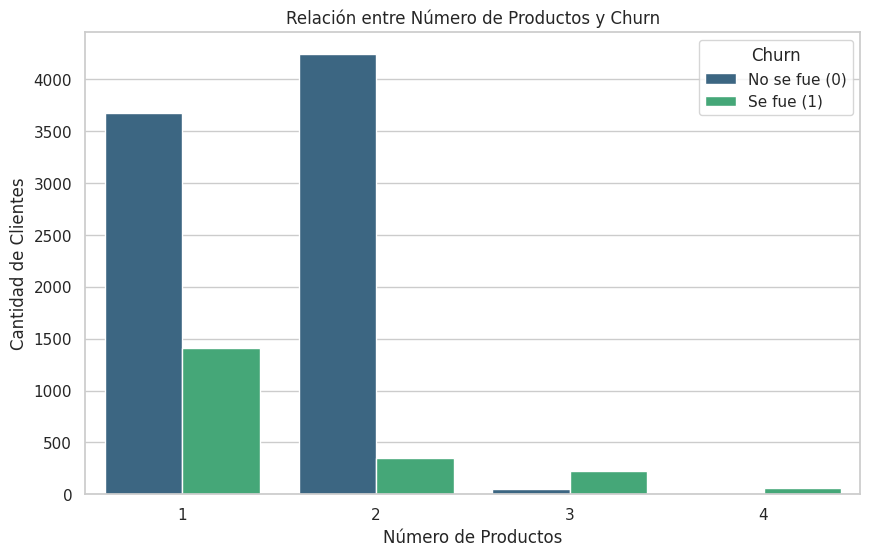

In [19]:
# para comparar los clientes que han abandonado contra clientes que tienen o han tenido 4 productos

churn_yes = df_bank_copy[df_bank_copy['churn']== 1] # para clientes que ya no están "churn" == 1
products_number_count = df_bank_copy['products_number'].value_counts().sort_values(ascending=False) # para calcular la frecuencia de products_number

#conteo general
print(f'Conteo de clientes por cantidad de productos')
print(products_number_count)

# Para crear la tabla de contingencia (frecuencias absolutas)
resumen_productos = pd.crosstab(df_bank_copy['products_number'], df_bank_copy['churn'])

# Calculando el porcentaje de Churn por cada grupo de producto (frecuencias relativas)
resumen_productos['% Churn'] = (resumen_productos[1] / (resumen_productos[0] + resumen_productos[1])) * 100

print("Análisis Numérico: Productos vs Churn")
print(resumen_productos)


#para crear gráfico
plt.figure(figsize=(10, 6))

# Usamos countplot directamente con el dataframe
# Esto segmenta automáticamente por el color de churn
sns.countplot(
    data=df_bank_copy,
    x='products_number',
    hue='churn',
    palette='viridis'
)

plt.title('Relación entre Número de Productos y Churn')
plt.xlabel('Número de Productos')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn', labels=['No se fue (0)', 'Se fue (1)'])
plt.show()

**Observaciones para products_number contra churn**

**1.- Abrumador resultado:** Todos los clientes con 4 productos abandonaron. Parece que la tendencia es "entre más productos más abandono". Noto el equilibrio en 2 productos.

Sería interesante tener el listado de los productos que posee cada cliente, así podríamos ver que productos son los que más afianzan a los clientes a la institución. Aunque me parece que el data set está limitado de información en ese sentido. Aún así el resultado es sumamente interesante.

La intuición indica que entre más productos tenga el cliente, más fiel será, pero la realidad dice lo contrario.

**2.- El Punto Óptimo (Sweet Spot):** Con 2 productos, el churn es apenas del $7.5%.$. Es el estado ideal. El cliente probablemente tiene su cuenta de ahorros probablemente ligado a la nómina y una tarjeta de crédito; está cómodo.

**3.- El Punto de Saturación:** Al saltar a 3 o 4 productos, el abandono se dispara. Esto sugiere que el cliente podría sentirse "abrumado" por tantos productos, llegando inclusive a un quebranto de sus líneas de crédito, y por ende, ya no está listado como cliente activo o churn == 1.





Porcentaje de Churn por Estatus de Actividad:
churn                  0          1
active_member                      
0              73.149103  26.850897
1              85.730926  14.269074


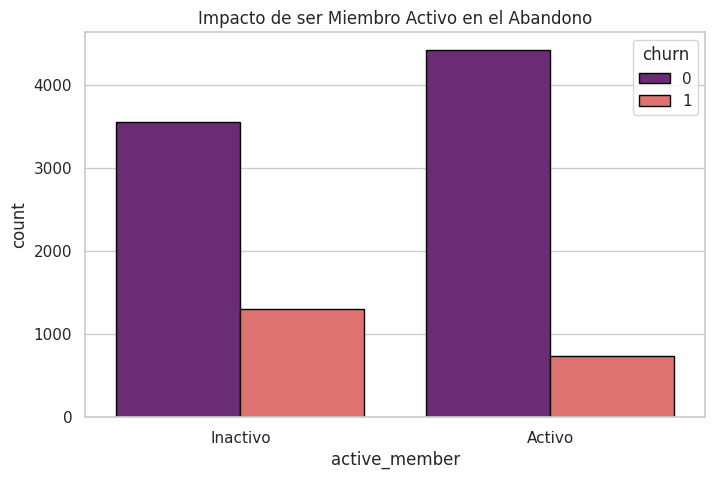

In [20]:
# Análisis de "Active Member" vs Churn

# Tabla de contingencia para Miembro Activo
resumen_activo = pd.crosstab(df_bank_copy['active_member'], df_bank_copy['churn'], normalize='index') * 100

print("Porcentaje de Churn por Estatus de Actividad:")
print(resumen_activo)

# Visualización
plt.figure(figsize=(8, 5))
sns.countplot(data=df_bank_copy, x='active_member', hue='churn', palette='magma', edgecolor = 'black')
plt.title('Impacto de ser Miembro Activo en el Abandono')
plt.xticks([0, 1], ['Inactivo', 'Activo'])
plt.show()

**Observaciones Active member contra Churn**

El objetivo de este análisis es determinar si la actividad reciente del cliente funciona como un factor protector contra el abandono. Se define como Miembro Activo a aquel cliente que ha mantenido interacción con el banco en el último periodo.

**Resultados Obtenidos:**

- Tasa de abandono en clientes inactivos: 26.85%

- Tasa de abandono en clientes activos: 14.27%

Esto evidencía lo lógico, que si el cliente es activo, es más complicado que pueda abandonar la institución, sin embargo, es necesario "verlo" y no darlo por hecho.



Análisis de Churn por País (%):
churn            0          1
country                      
France   83.845233  16.154767
Germany  67.556796  32.443204
Spain    83.326605  16.673395


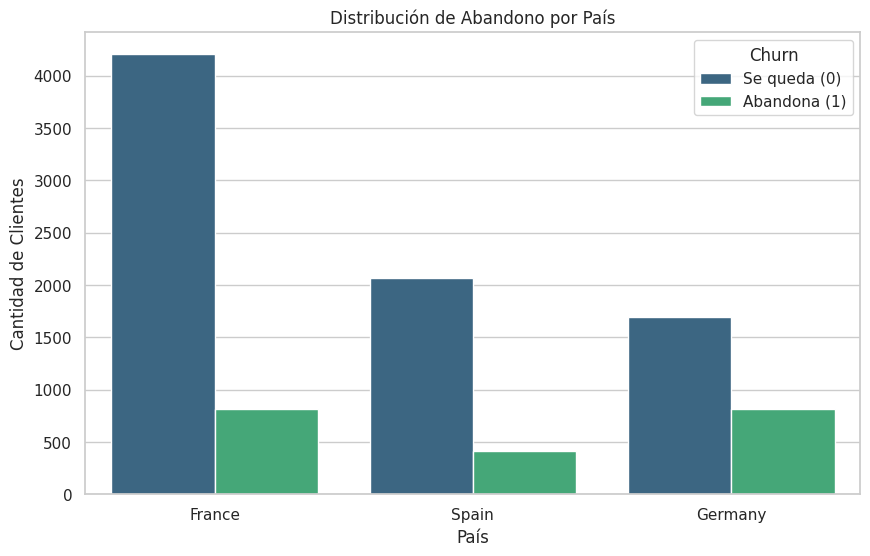

In [21]:
# Análisis de Country contra Churn

# Tabla de contingencia para Country vs Churn (Normalizada para ver porcentajes)
resumen_pais = pd.crosstab(df_bank_copy['country'], df_bank_copy['churn'], normalize='index') * 100

print("Análisis de Churn por País (%):")
print(resumen_pais)

# Visualización para comparar el volumen y la proporción
plt.figure(figsize=(10, 6))
sns.countplot(data=df_bank_copy, x='country', hue='churn', palette='viridis')
plt.title('Distribución de Abandono por País')
plt.xlabel('País')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Churn', labels=['Se queda (0)', 'Abandona (1)'])
plt.show()

**Observaciones para Country contra Churn**

Se identifica una anomalía geográfica en Alemania, donde la tasa de abandono (32.4%) duplica a la de Francia y España. Esto sugiere problemas específicos de mercado o competitividad en dicha región.

**Competencia:** ¿Hay un banco (digital o tradicional) fuerte en Alemania que le está robando mercado a nuestra institución?

**Servicio:** ¿La infraestructura del banco en Alemania es peor o tiene comisiones más altas en comparación con las del mercado?

**Perfil del cliente:** ¿El cliente alemán de este dataset es más propenso a cambiar de banco si no ve beneficios inmediatos?

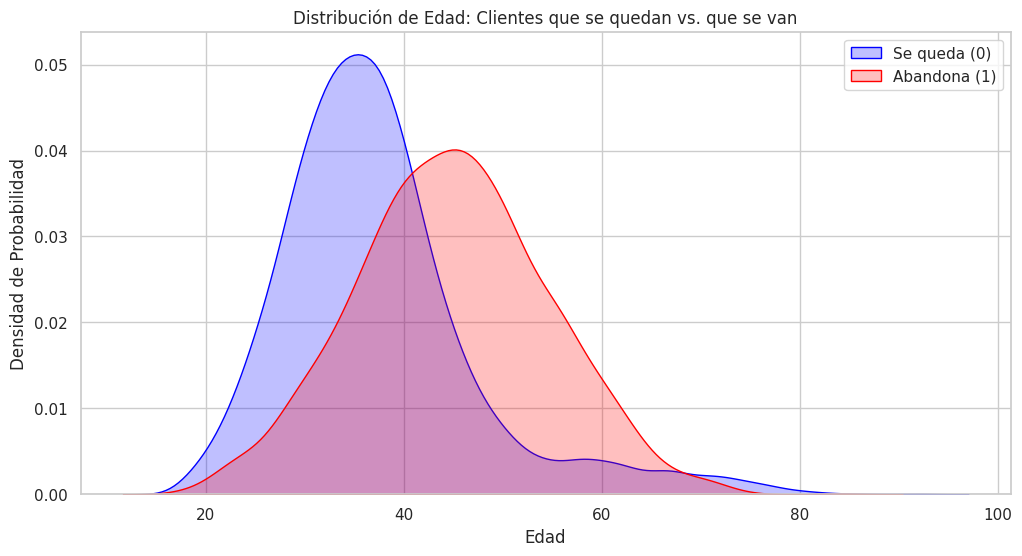

Estadísticas de Edad por Churn:
        count       mean        std   min   25%   50%   75%   max
churn                                                            
0      7963.0  37.408389  10.125363  18.0  31.0  36.0  41.0  92.0
1      2037.0  44.837997   9.761562  18.0  38.0  45.0  51.0  84.0


In [22]:
# Análisis de Age contra Churn
plt.figure(figsize=(12, 6))

# Gráfico de Densidad (KDE) para ver las "curvas" de edad
sns.kdeplot(data=df_bank_copy[df_bank_copy['churn'] == 0], x='age', fill=True, label='Se queda (0)', color='blue')
sns.kdeplot(data=df_bank_copy[df_bank_copy['churn'] == 1], x='age', fill=True, label='Abandona (1)', color='red')

plt.title('Distribución de Edad: Clientes que se quedan vs. que se van')
plt.xlabel('Edad')
plt.ylabel('Densidad de Probabilidad')
plt.legend()
plt.show()

# Resumen estadístico numérico
print("Estadísticas de Edad por Churn:")
print(df_bank_copy.groupby('churn')['age'].describe())

**Observaciones para Age contra Churn**

**El Factor Edad.**

Existe una correlación positiva entre la edad y el churn hasta llegar a un pico crítico entre los 40 y 50 años. Mientras que la edad mediana de los clientes leales es de 36 años, los clientes que abandonan presentan una mediana de 45 años. Esto sugiere que las estrategias de retención actuales están fallando en el segmento de clientes con mayor estabilidad financiera.

**¿Por qué esto es una "Alerta Roja" para el banco?**

A diferencia de los jóvenes de 20 años, los clientes de 40 a 50 años suelen ser el segmento más rentable:

- Tienen salarios más altos (más comisiones por manejo de cuenta).

- Tienen más ahorros (mayor balance).

- Tienen más necesidades de crédito (hipotecas, préstamos para empresas).

**Insight:** El banco está perdiendo a su segmento de mayor valor. No es un abandono de "estudiantes", es un abandono de "profesionales consolidados".

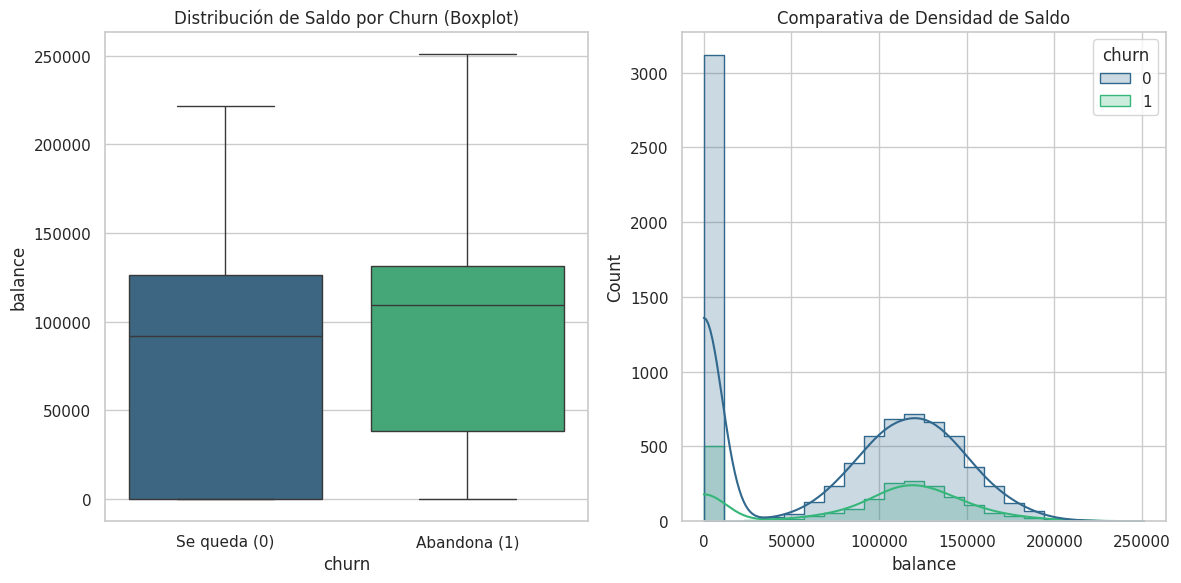

Estadísticas de Saldo por Churn:
        count          mean           std  min       25%        50%  \
churn                                                                 
0      7963.0  72745.296779  62848.040701  0.0      0.00   92072.68   
1      2037.0  91108.539337  58360.794816  0.0  38340.02  109349.29   

             75%        max  
churn                        
0      126410.28  221532.80  
1      131433.33  250898.09  


In [23]:
# Análisis de Balance contra Churn

plt.figure(figsize=(12, 6))

# 1. Boxplot: Corregido asignando churn a hue
plt.subplot(1, 2, 1)
sns.boxplot(data=df_bank_copy, x='churn', y='balance', hue='churn', palette='viridis', legend=False)
plt.title('Distribución de Saldo por Churn (Boxplot)')
plt.xticks([0, 1], ['Se queda (0)', 'Abandona (1)'])

# 2. Histograma
plt.subplot(1, 2, 2)
sns.histplot(data=df_bank_copy, x='balance', hue='churn', kde=True, element="step", palette='viridis')
plt.title('Comparativa de Densidad de Saldo')

plt.tight_layout()
plt.show()

# 3. Estadística descriptiva
print("Estadísticas de Saldo por Churn:")
print(df_bank_copy.groupby('churn')['balance'].describe())

**Observación de Balance contra Churn**

**El saldo como predictor de abandono.**

**Los clientes con saldo 0 son más leales:** Existe una gran base de clientes con cuenta en ceros que no muestra intención de irse, sin embargo, tampoco son de gran utilidad para el banco, ya que , probablemente solo tienen la nómina, y en cuanto esta cae, de inmediato la retiran, por lo que el banco no tiene tiempo de mover su dinero a créditos para otros clientes, por lo que no genera interés para los propios clientes ni utilidades para el banco.

**Fuga de capital:** Los clientes que abandonan tienen, en promedio, un saldo mayor que los que se quedan. De a cuerdo con los boxplot, la mediana de los clientes que se queda está al rededor de los $90mil$, mientras que la de los que se van está por enciema de los $110mil$. Esto confirma la suposición de puntos anteriores, dónde se notaba una inclinación a que el abandono mayoritariamente se da en clientes de mejor perfil socioeconómico.

**Punto crítico:** El riesgo de Churn aumenta significativamente en clientes con ahorros entre $100k$ y $150k$. El banco está perdiendo a sus clientes más rentables como se ha mencionado ya.

--------------------------------------------------------------

**Conclusión del Análisis Bivariado**

De acuerdo con el análisis previo se detecta un perfil para clientes con altas probabilidades de abandono:

- Tiene entre 3 y 4 productos.

- Vive en Alemania.

- Tiene entre 40 y 50 años.

- Tiene un saldo alto (más de $100k) o es inactivo.

-----------------------------------------------------

***Fase 4. Ingeniería de características***

Para la presente etapa del proceso será necesario mapear a numéros algunas variables. Esto se hace debido a que el modelo de ML que se implementará más adelante no es capáz de entender palabras, sino números.

Además, este paso es fundamental para un análisis posterior acerca de una visualización de matríz de correlación, esto permitirá verificar que tanto influye una variable sobre otra. De nuevo, este proceso solo es viable teniendo las variables en "números".

In [24]:
# primero se procede a verificar el formato que tiene cada una de las variables:
print("---Variables Binarias---")
print(df_bank_copy[variables_binarias].head(3))

print("\n---Variables Nominales---")
print(df_bank_copy[variables_nominales].head(3))

print("\n---Variables Numéricas---")
print(df_bank_copy[variables_numéricas].head(3))

---Variables Binarias---
   credit_card  active_member  churn
0            1              1      1
1            0              1      0
2            1              0      1

---Variables Nominales---
  country  gender
0  France  Female
1   Spain  Female
2  France  Female

---Variables Numéricas---
   credit_score  age  tenure    balance  products_number  estimated_salary
0           619   42       2       0.00                1         101348.88
1           608   41       1   83807.86                1         112542.58
2           502   42       8  159660.80                3         113931.57


In [25]:
# Cómo se pudo visualizar recientemente, las se deben transformar las variables nominales.
# Las variables nominales ya tienen un formato correcto y aunque las numéricas pudiera parecer que no,
# esto no es así, ya que el tipo float deriva de la naturaleza de la propia variable monetaria.

# Aplicando método de One Hot Encoding para variables nominales
df_bank_copy = pd.get_dummies(df_bank_copy, columns=variables_nominales, drop_first=True)

In [26]:
# Verificando las nuevas dimensiones de las solumnas del dataset
print(f'Total de columnas posterior a la transformación: {df_bank_copy.shape[1]}')

#Verificando la nueva estructura del dataset
df_bank_copy.head()


Total de columnas posterior a la transformación: 12


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [27]:
# se puede observar la correcta transformación de las variables. Originalmente se tenían 12 columnas, sin embargo se eliminó customer_id
# en una etapa temprana, por lo que se continuó trabajando con 11.

# Al ejecutar el "get_dummies" se eliminaron las variables de "country" y "gender", por lo que el dataset quedó con 9 variables.

# Se crean las variables "country_Germany", "country_Spain" y "gender_Male", dando un total de 12 variables nuevamente.

# Las nuevas variables se crean en formato True y False, que en esencia son 1 y 0, por lo que no genera conflicto trabajar con estas en dicho formato,
# sin embargo, para mantener la coherencia de sintaxis se prodecederá a cambiar el formato a 1 y 0 de manera explicita.

df_bank_copy = df_bank_copy.replace({False: 0, True: 1})
df_bank_copy.head()

/tmp/ipykernel_9895/1336906196.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_bank_copy = df_bank_copy.replace({False: 0, True: 1})


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


------------------------------------------------------------------

**Variables adicionales**

Durante la etapa de "Ingeniería de características" es viable eliminar o crear nuevas variables (o características). En este caso se procederá a crear 3 nuevas variables basados en hallazgos durante la etapa de EDA.

**1. Balance por Producto (balance_per_product)**

**Detonante del EDA:** Se notó que los clientes con 3 o 4 productos tienen una fuerte tasa de abandono.

**Observación:** El número de productos por sí solo es una cantidad, y el saldo por sí solo es capital. Sin embargo, la densidad financiera (cuánto dinero hay en cada producto) puede indicar si el cliente usa el banco como su cuenta principal o si solo tiene productos "vacíos" o secundarios que para él no tienen mucha importancia. Un saldo alto repartido en muchos productos podría indicar una relación compleja con el abandono, en el sentido de que el cliente prefiere simplificar cerrando la cuenta y unificando sus productos en uno solo con otra institución.

**2. Salario Relativo (balance_salary_ratio)**

**Detonante del EDA:** Se identificó que los clientes con saldos entre $100k$ y $150k$ son los más propensos a irse.

**Observación**: No es lo mismo tener $100k$ ahorrados si se gana $50k$ al año, que si se gana $200k$. En el primer caso, el banco tiene una captación fuerte de los ahorros del cliente (dependencia alta). En el segundo, es solo una fracción pequeña. Esta variable podría medir la "lealtad financiera" o el peso que tiene el banco en el patrimonio total estimado del usuario.

**3. Segmentación de Score (credit_score_range)**

**Detonante del EDA:** Se notó que el perfil de abandono tiende a ser de un nivel socioeconómico "mejor" (saldos altos).

**Observación:** Los modelos lineales (como la Regresión Logística) a veces tienen dificultades para encontrar patrones en números continuos si el comportamiento no es lineal. Al crear rangos de riesgo (Pobre, Excelente, etc.), se transforma una medida técnica en una jerarquía de valor para el banco. Esto permite identificar si el banco está perdiendo específicamente a sus clientes "Premium" o "AAA" como previamente se sugirió.

A coninuación se detalla la justificación técnica para la presente variable, ya que delas nuevas, es la más sofisticada matemáticamente.

**Justificación Técnica: Creación de credit_score_range**

La creación de esta variable no es una simple agrupación estética, sino una estrategia de optimización predictiva basada en tres puntos a destacar:

**1. Captura de Relaciones No Lineales**

La Regresión Logística asume que el riesgo de Churn aumenta o disminuye de forma constante (lineal) con el puntaje de crédito. Sin embargo, en el comportamiento bancario, el riesgo suele ser dispar, es decir, un cliente con puntaje "Pobre" puede irse por falta de acceso a crédito o inclusive por quebranto de sus líneas de crédito, mientras que uno "Excelente" puede irse por ofertas de la competencia.

**El beneficio:** Al segmentar en rangos, permitimos que el modelo asigne un peso específico a cada grupo de riesgo, detectando patrones que una simple línea recta ignoraría (en caso de que se decidiera trabajar solo con la variable score).

**2.-Reducción de Ruido (Robustez del modelo ante la constante variabilidad)**

Pequeñas variaciones de 5 o 10 puntos en el credit_score (por ejemplo 650 vs 655) son poco probables de cambiar el comportamiento real de un cliente.

Al agrupar, esperaríamos minimizar el "ruido" de las fluctuaciones menores y nos enfocaríamos en el perfil crediticio general de cada segmento de la variable (Pobre, Regular, Bueno), lo que ayuda a que modelos como Random Forest y XGBoost encuentren cortes más significativos y generalizables.

**3. Interpretabilidad y Estrategia de Negocio (XAI)**

Para la etapa final del proyecto (Conclusiones y Estrategia), es mucho más importante informar al banco que los clientes en el rango "Promedio" o "Regular" tienen un 20% más de probabilidad de fuga que dar una cifra basada en puntos individuales.

**El beneficio**: Facilita la creación de campañas de retención diferenciadas. No se le ofrece lo mismo a un cliente "AAA" que a uno en riesgo "Pobre".

**En resumen:**  Se implementa la segmentación de credit_score para transformar una variable continua en una jerarquía de valor. Esto permite a la Regresión Logística modelar comportamientos no lineales y mejora la interpretabilidad de los resultados, alineando el modelo con las categorías de riesgo reales utilizadas en el sector financiero, además de ayudar a los modelos basados en árboles a realizar cortes más claros.

-----------------------------------------------------------

In [28]:
# Para "balance_per_product": Representa la cantidad promedio de capital que el cliente tiene en cada producto contratado.

# Duarante el EDA se verificó que ningún cliente tuviera "0" productos, solo se detectaron clientes que manejan de 1 a 4.
# Sin embargo, se procede a verificar para no crear conflico en el código antes de crear la nueva variable.

# En principio, no tiene sentido la existencia de un cliente si no tiene contratado al menos un producto, sin embargo,
# este podría existir debido a un error de captura.

print(f'Clientes con cero prodcutos: {(df_bank_copy['products_number'] == 0).sum()}')

Clientes con cero prodcutos: 0


In [29]:
# Creación de balance_per_product
df_bank_copy['balance_per_product'] = df_bank_copy['balance'] / df_bank_copy['products_number']

# Se consulta una muestra para verificar la correcta creación de la variable
df_bank_copy[['balance', 'products_number', 'balance_per_product']].head()



,balance,products_number,balance_per_product
0,0.00,1,0.000000
1,83807.86,1,83807.860000
2,159660.80,3,53220.266667
3,0.00,2,0.000000
4,125510.82,1,125510.820000


**Observaciones**

- fila 0: Balance de 0.0 con 1 producto = 0.0. Cliente con cuenta activa pero vacía.

- Fila 1: Balance de $83,807.86$ con 1 producto = $83,807.86$. Todo su capital en un solo lugar.

- Fila 2: Aquí es donde se confirma el correcto funcionamiento de la variable. El balance es alto ($159,660.80$), pero al tener 3 productos, la densidad por producto baja a $53,220.26$.

  **Dato clave:** Este es precisamente el perfil que se mencionó anteriormente:

  Clientes con muchos productos que podrían estar "diluyendo" su relación con el banco.

- Fila 3: Balance de 0.0 con 2 productos = 0.0.

- Fila 4: El balance más alto de la muestra ($125,510.82$) concentrado en 1 solo producto.

-----------------------------------------------------------------

In [30]:
# Para balance_salary_ratio: Divide el saldo individual de cada cliente entre su salario estimado para conocer la proporción de su patrimonio en el banco.

# Creación de balance_salary_ratio
df_bank_copy['balance_salary_ratio'] = df_bank_copy['balance'] / df_bank_copy['estimated_salary']

# Se consulta una muestra para asegurar que la relación sea lógica
df_bank_copy[['balance', 'estimated_salary', 'balance_salary_ratio']].head()



,balance,estimated_salary,balance_salary_ratio
0,0.00,101348.88,0.000000
1,83807.86,112542.58,0.744677
2,159660.80,113931.57,1.401375
3,0.00,93826.63,0.000000
4,125510.82,79084.10,1.587055


**Observaciones**

- Fila 1: El cliente tiene ahorrado el 74% de lo que gana en un año. Es una relación sólida.

- Fila 2: El cliente tiene el 140% de su salario anual en el banco. Esto significa que tiene más ahorros que su ingreso de todo un año. Es un cliente "patrimonial" muy importante.

- Fila 4: Misma lógica del caso anterior, con un 158%.

Matemáticamente, se ha pasado de tener dos números planos a tener una métrica de intensidad. Para un modelo, es más fácil detectar el riesgo en un "1.58" que comparando dos números de seis cifras por separado.

-----------------------------------------------------------------------

---Estadísticas estándar de la variable: credit_score---
count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: credit_score, dtype: float64


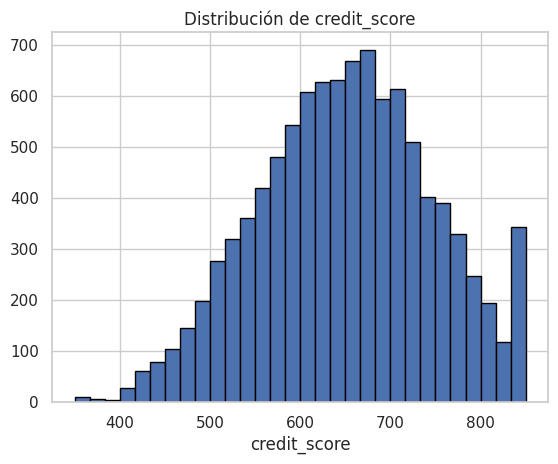

In [31]:
# Para 'credit_score_range' : Que funcionará como un segmentador de tipo de cliente basado en el score de este.

# Se retoma la variable a trabajar, reiterando su distribución y estadísticas básicas.

print(f'---Estadísticas estándar de la variable: credit_score---')
print(df_bank_copy['credit_score'].describe())

plt.hist(df_bank_copy['credit_score'], bins=30, edgecolor='black')
plt.title('Distribución de credit_score')
plt.xlabel('credit_score')
plt.show()

**Observaciones**

De acuerdo con las estadísticas de la variable "credit_score" se ha decidido trabajar con los siguientes segmentos: [300, 580, 670, 740, 800, 850]

**1.- Densidad de la Población**

Como se puede notar, no son cortes simétricos, esto es debido a que la mayoría de los clientes en un banco no están en los extremos. Si hiciéramos segmentos simétricos, por ejemplo de 300 a 400, se tendría muy pocos clientes (de acuerdo a la distribución anterior), lo que no le daría mucha información de aprendizaje a los modelos. Sin embargo de 600 a 700 se tendrían cerca de 5,000, lo que provocaría que el modelo le diera un peso "arficial" al segmento, creyendo que este es más importante que los demás, por lo que se podría sesgar el aprendizaje.

- El salto de 280 (300 a 580): Se hace tan grande porque , como se ha mencionado, hay muy poca gente con puntajes extremadamente bajos. Agrupamos a todos los "Pobres" en un solo segmento grande porque, para el banco, alguien con 350 o 450 representa un riesgo crítico similar.

- El salto de 50 (800 a 850): En el tope de la pirámide, el comportamiento cambia con muy pocos puntos. Un cliente de 820 es muy distinto a uno de 750 en términos de lealtad y productos. Necesitamos poner mucha atención en los puntajes altos para ver si los clientes Premium se están yendo.

-----------------------------------------------------

**2.- Puntos de Corte Bancarios**

Los bancos utilizan reglas de negocio predefinidas. En el mundo real (como el sistema FICO), los rangos suelen verse así:

- 300-579: Malo (Default casi seguro).

- 580-669: Regular (Riesgo moderado).

- 670-739: Bueno (Promedio).

- 740-799: Muy Bueno (Preferencial).

- 800-850: Excepcional (Premium).

Al usar estos rangos, se pretende alienar el modelo de Machine Learning con la realidad operativa del sector financiero. El modelo aprenderá "fronteras" que el banco ya reconoce.

**Referencias**:

https://www.creditosenusa.com/que-es-fico-score/

https://www.fico.com/es/products/fico-score

---------------------------------------------------

**En resumen:** Esta segmentación asimétrica busca compensa la alta densidad de datos en el centro de la distribución y aplica una "lupa" en los extremos, permitiendo que los modelos (especialmente la Regresión Logística) detecten fronteras de comportamiento que no son visibles de forma lineal.

In [32]:
# Creación de la variable Segmentación de Score
# Definimos los niveles de riesgo crediticio basados en estándares bancarios

# Definimos los puntos de corte (bins) y las etiquetas (labels)
bins = [300, 580, 670, 740, 800, 850]
labels = ['Pobre', 'Regular', 'Bueno', 'Muy Bueno', 'Excelente']

df_bank_copy['credit_score_range'] = pd.cut(df_bank_copy['credit_score'], bins=bins, labels=labels) #construyendo la nuev variable

# consultando una muestra para verificar la correcta creación
print("Muestra para confirmar la ejecución correcta")
print(df_bank_copy[['credit_score','credit_score_range']].head())
print("\nConteo por rango:")
# Para ordenar por la etiqueta del rango (Excelente hasta Pobre)
print(df_bank_copy['credit_score_range'].value_counts().sort_index(ascending=False))



Muestra para confirmar la ejecución correcta
   credit_score credit_score_range
0           619            Regular
1           608            Regular
2           502              Pobre
3           699              Bueno
4           850          Excelente

Conteo por rango:
credit_score_range
Excelente     645
Muy Bueno    1215
Bueno        2397
Regular      3350
Pobre        2393
Name: count, dtype: int64


/tmp/ipykernel_9895/859383569.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_bank_copy, x='credit_score_range', order=orden_logico, palette="viridis")


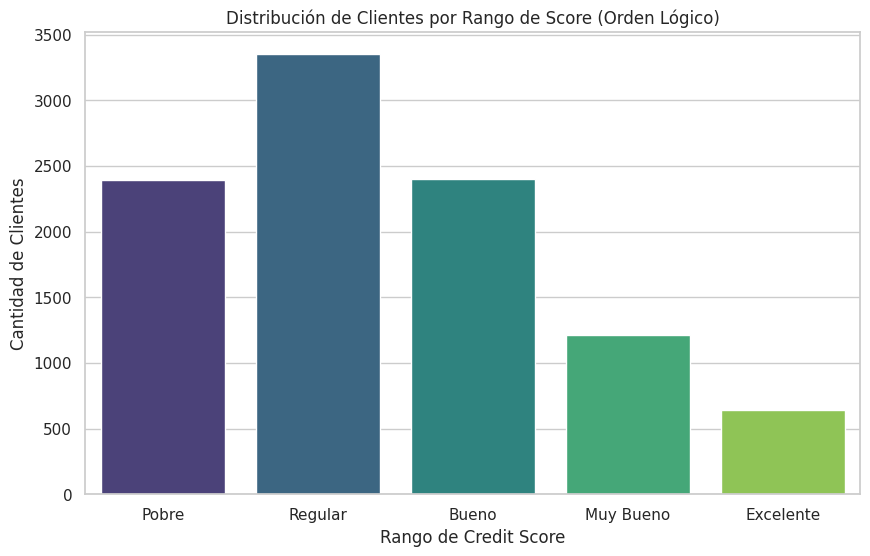

In [33]:
# Verificando la distribución de la nueva variable

# Definimos el orden deseado
orden_logico = ['Pobre', 'Regular', 'Bueno', 'Muy Bueno', 'Excelente']

# Creamos el gráfico indicando el orden
plt.figure(figsize=(10, 6))
sns.countplot(data=df_bank_copy, x='credit_score_range', order=orden_logico, palette="viridis")

plt.title('Distribución de Clientes por Rango de Score (Orden Lógico)')
plt.xlabel('Rango de Credit Score')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [34]:
# La recien creada variable, aunque deriva de una característica numérica, terminó siendo una categorica ordinal,
# por lo que, para que esta pueda ser interpretada de manera correcta por los modelos, además de ser utilizada para
# el análisis de correlación, se deberá mapear para asignar un nivel a cada uno de los segmentos.

# Creando las jerarquías
mapeo_credit_score_range = {
    'Pobre': 0,
    'Regular': 1,
    'Bueno': 2,
    'Muy Bueno': 3,
    'Excelente': 4
}

# mapeando la variable
df_bank_copy['credit_score_range'] = df_bank_copy['credit_score_range'].map(mapeo_credit_score_range)

# verificando mapeo correcto
print(f'Ahora los niveles de credit_score_range son: {df_bank_copy['credit_score_range'].value_counts()}')

Ahora los niveles de credit_score_range son: credit_score_range
1    3350
2    2397
0    2393
3    1215
4     645
Name: count, dtype: int64


In [35]:
# Antes de continuar a la siguiente etapa se procede a verificar las dimensiones y una muestra del dataset posterior a las modificaciones
print(f'Las dimensiones del dataset son: {df_bank_copy.shape[0]} filas con {df_bank_copy.shape[1]} columnas.')
df_bank_copy.head()

Las dimensiones del dataset son: 10000 filas con 15 columnas.


,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male,balance_per_product,balance_salary_ratio,credit_score_range
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0,0.000000,0.000000,1
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0,83807.860000,0.744677,1
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0,53220.266667,1.401375,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0,0.000000,0.000000,2
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0,125510.820000,1.587055,4


---------------------------------------------------------------

***Fase 5: Análisis de correlación***

Para garantizar la robustez de los modelos, especialmente en la Regresión Logística, es fundamental mitigar la multicolinealidad. Este fenómeno ocurre cuando dos o más variables independientes están altamente correlacionadas, lo que dificulta que el modelo asigne pesos (**coefficients**) precisos y estables a cada característica.

En esta fase, utilizaremos una matriz de correlación de Pearson para identificar y eliminar redundancias, asegurando que cada variable aporte información única al sistema. Asimismo, evaluaremos la fuerza de la relación entre nuestras nuevas variables de ingeniería y la variable objetivo (Exited), validando así su potencial capacidad predictiva antes de iniciar el entrenamiento.

In [36]:
# Para calcular la matriz de correlación

matriz_correlacion = df_bank_copy.corr()

# Para extraer solo la relación con Churn y ordenamos
relacion_con_churn = matriz_correlacion['churn'].sort_values(ascending=False)

# Para conocer variables que influyen más o menos en el abandono del cliente

print("Top 3 Factores que IMPULSAN el abandono (Correlación Positiva):")
print(relacion_con_churn.head(4)) # se solicitan 4 ya que Churn contra Churn no se debe tomar en cuenta al ser la misma variable

print("\nTop 3 Factores que RETIENEN el abandono (Correlación Negativa):")
print(relacion_con_churn.tail(3))

Top 3 Factores que IMPULSAN el abandono (Correlación Positiva):
churn              1.000000
age                0.285323
country_Germany    0.173488
balance            0.118533
Name: churn, dtype: float64

Top 3 Factores que RETIENEN el abandono (Correlación Negativa):
country_Spain   -0.052667
gender_Male     -0.106512
active_member   -0.156128
Name: churn, dtype: float64


**Observaciones**

Como se aprecia, en el reciente análisis de correlación se confirman hipótesis lanzadas durante la **Fase 3: EDA:**

- 1. El factor age (Edad): El predictor más fuerte.

  **En el EDA:** Los gráficos de densidad (KDE) muestran claramente un desplazamiento hacia la derecha en los clientes que abandonan (churn=1). La curva de los que se quedan tiene su pico cerca de los 35 años, mientras que la de los que se van se sitúa entre los 45 y 55 años.

  **En la Correlación: Es tu líder positivo (0.28).**

  **Interpretación:** No es una relación lineal perfecta, es un cambio de comportamiento generacional. Los clientes en edad de mayor estabilidad financiera o planificación de retiro parecen estar reevaluando su relación con el banco, y al final del día, son los que se terminan yendo.

- 2. El fenómeno country_Germany vs country_Spain

  **En el EDA:** Se observa una tasa de abandono desproporcionadamente alta en Alemania. Los gráficos de barras muestran que casi 1 de cada 3 alemanes se va, mientras que en España y Francia la proporción es mucho menor.

  **En la Correlación: Alemania aparece como el segundo factor de impulso (0.17) y España como un factor de retención (-0.05).**

  **Interpretación:** Hay algo en el mercado alemán (quizás una oferta de un banco competidor muy agresiva o insatisfacción con un producto específico de esa región) que es un motor crítico de fuga. El modelo deberá ser muy sensible a esta geografía. Adicionalmente es impoportante mencionar dicho insights al área de **producto** encargada de dicha región.

- 3. balance (Saldo) y sus nuevas variables

  **En el EDA:** Se vio que la mediana del saldo de los clientes que se van es superior a la de los que se quedan. Esto es contra-intuitivo para algunos, pero común en banca: el cliente con más dinero es más exigente y tiene más opciones.

  **En la Correlación: El balance tiene un 0.11.**

  **Interpretación:** Aquí es donde las nuevas variables (balance_per_product y balance_salary_ratio) se destacan. Aunque no aparezcan en el "Top 3" de correlación lineal simple, en el EDA se nota que el número de productos (products_number) es un factor determinante. Al haber creado balance_per_product, se le está dando al modelo una forma de ver si el cliente está "muy cargado" en pocos productos, lo cual suele ser señal de riesgo.

- 4. active_member: El ancla de lealtad

  **En el EDA:** La diferencia en la tasa de churn entre miembros activos y no activos es muy notoria en las visualizaciones.

  **En la Correlación: Es el factor de retención más fuerte (-0.16).**

  **Interpretación:** Esto valida que la estrategia de retención no solo debe ser financiera, sino de "engagement". El cliente que no usa la cuenta es un cliente que ya se fue mentalmente.

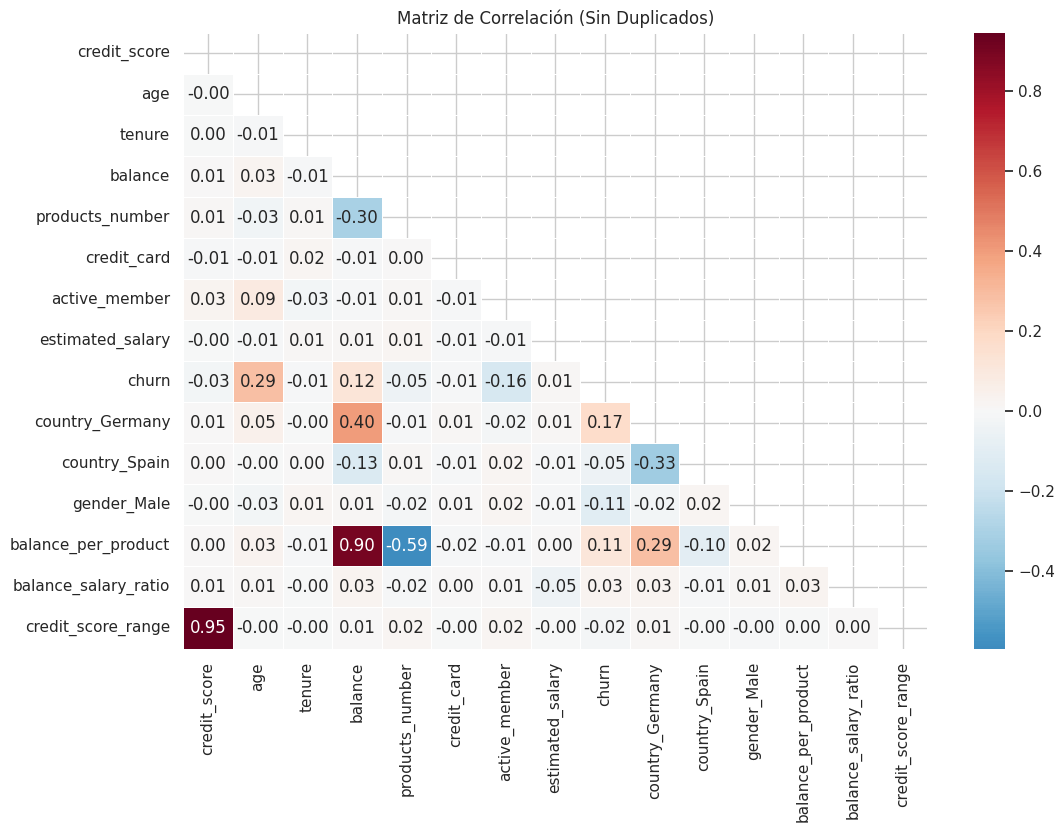

In [37]:
# Ahora que ya conocemos las correlaciones con la variable target, es necesario conocer la matríz general
# Esto se hace c on la finalidad de eliminar variables redundantes que pudieran causar ruido a los modelos.

# Se calculamos la matriz de correlación completa
matriz_completa = df_bank_copy.corr()

# Se crea una máscara para el triángulo superior, con la finalidad de no tener el efecto espejo
# np.triu_indices_from crea los índices para la parte de arriba;
# np.zeros_like crea una matriz de ceros con la misma forma
mask = np.triu(np.ones_like(matriz_completa, dtype=bool))

# Para visualizar la matríz
plt.figure(figsize=(12, 8))

sns.heatmap(matriz_completa,
            mask=mask,          # Aplicamos la máscara aquí
            annot=True,
            fmt=".2f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación (Sin Duplicados)')
plt.show()

In [38]:
# Para obtener las pareja con correlaciones más altas:

# Obtenemos la matriz de correlación en valor absoluto (nos interesa la fuerza, sea + o -)
matriz_completa_abs = df_bank_copy.corr().abs()

# Se converte la matriz en una serie de pares y se elimina los duplicados (la diagonal y el espejo)
sol = (matriz_completa_abs.where(np.triu(np.ones(matriz_completa_abs.shape), k=1).astype(bool))
                  .stack()
                  .sort_values(ascending=False))

# 3. Mostramos los pares con mayor correlación
print("Pares de variables con mayor correlación:")
print(sol.head())

Pares de variables con mayor correlación:
credit_score     credit_score_range     0.946805
balance          balance_per_product    0.901862
products_number  balance_per_product    0.594726
balance          country_Germany        0.401110
country_Germany  country_Spain          0.332084
dtype: float64


**Observaciones**

**Eliminación de Redundancia Crítica ($Credit\_Score$):**

 Se detectó una correlación del 0.95 entre el valor bruto y el rango segmentado. Se decide conservar únicamente credit_score_range, ya que su naturaleza ordinal captura mejor la jerarquía de riesgo bancario y minimiza el ruido de fluctuaciones menores, facilitando la generalización en modelos de árboles.

 **Optimización del Balance ($Balance\_per\_product$):**

 La correlación del 0.90 entre el saldo total y el saldo por producto indica una redundancia elevada. Se opta por priorizar balance_per_product, dado que es una variable más "inteligente" que integra el nivel de ahorro con la diversificación de productos del cliente, mostrando además una correlación ligeramente superior con el churn.

 **Validación de Variables Sintéticas ($Balance\_Salary\_Ratio$):**

 A diferencia de las anteriores, esta variable presenta correlaciones moderadas con sus fuentes ($< 0.50$), lo que confirma que aporta información nueva y no redundante sobre la salud financiera del cliente, siendo apta para fortalecer el poder predictivo del modelo.

 **Identificación de Predictores Clave :**

 El análisis confirma a la Edad(age), la Ubicación (country_Germany) y el Estatus de Miembro Activo (active_member) como los factores con mayor impacto directo en el abandono. Esta jerarquía valida los hallazgos del análisis bivariado y servirá como base para la interpretación de los pesos en la etapa de modelado.

In [39]:
# Para eliminar variables redundantes

variables_a_eliminar = ['credit_score', 'balance']

#Para instanciar el objeto a modelar
df_final = df_bank_copy.drop(columns=variables_a_eliminar)

# Para cconocer las simensiones del objeto
print(f'Las dimensiones del dataset son: {df_final.shape[0]} filas con {df_final.shape[1]}) columnas.')
df_final.head()

Las dimensiones del dataset son: 10000 filas con 13) columnas.


,age,tenure,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male,balance_per_product,balance_salary_ratio,credit_score_range
0,42,2,1,1,1,101348.88,1,0,0,0,0.000000,0.000000,1
1,41,1,1,0,1,112542.58,0,0,1,0,83807.860000,0.744677,1
2,42,8,3,1,0,113931.57,1,0,0,0,53220.266667,1.401375,0
3,39,1,2,0,0,93826.63,0,0,0,0,0.000000,0.000000,2
4,43,2,1,1,1,79084.10,0,0,1,0,125510.820000,1.587055,4


------------------------------------------------------------

***Fase 6: Preparación para los modelos y escalado***

-------------------------------------------

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1.- Separación de variables predictoras y variable objetivo
X = df_final.drop(columns=['churn']) # Usamos X mayúscula por convención de matriz
y = df_final['churn']

# 2.- Separando en sets de prueba y entrenamiento (80/20) y estratificado por desbalance
# Corregido: Pasamos X (mayúscula)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3.- Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Ajusta y transforma
X_test_scaled = scaler.transform(X_test)      # Solo transforma para evitar Data Leakage

# 4.- Verificación
print('Preparación completa')
print(f'El tamaño de la muestra para entrenamiento es de {X_train_scaled.shape[0]} observaciones.')
print(f'El tamaño de la muestra para validación es de {X_test_scaled.shape[0]} observaciones.')

Preparación completa
El tamaño de la muestra para entrenamiento es de 8000 observaciones.
El tamaño de la muestra para validación es de 2000 observaciones.


-------------------------------------------

***Fase 7: Modelado***

-----------------------------------------------------------------

**Modelo 1: Regresión logística**

In [41]:
#--- ESTAPA DE ENTRENAMIENTO ---#

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

#1.- Se define la estrategía de validación cruzada con la finalidad de evitar el sobreajuste
skf_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2.- Instanciando el modelo considerando el desbalance
modelo_logistico = LogisticRegression(class_weight='balanced',
                                      random_state=42,
                                      max_iter=1000)

# 3.- . Se ejecuta la validación sobre el set de entrenamiento escalado
# Nota: La validación cruzada se hace sobre TRAIN. El set TEST sigue guardado bajo llave.
scores = cross_val_score(modelo_logistico, X_train_scaled, y_train, cv=skf_shuffle, scoring='roc_auc')

# 4. Resultados
print(f"--- VALIDACIÓN CRUZADA: REGRESIÓN LOGÍSTICA ---")
print(f"Scores individuales: {scores}")
print(f'Diferencia entre máximo score y mínimo score: {scores.max() - scores.min():.4f}')
print(f"ROC-AUC promedio: {scores.mean():.4f}")
print(f"Promedio de desviación estándar: {scores.std():.4f}")


--- VALIDACIÓN CRUZADA: REGRESIÓN LOGÍSTICA ---
Scores individuales: [0.76214474 0.78331134 0.79104988 0.73164325 0.75950342]
Diferencia entre máximo score y mínimo score: 0.0594
ROC-AUC promedio: 0.7655
Promedio de desviación estándar: 0.0208


**Observaciones**

Se implementó un modelo de Regresión Logística como punto de referencia (Baseline), utilizando una estrategia de Validación Cruzada Estratificada (5-folds) para garantizar la robustez estadística y mitigar el sobreajuste. Se aplicó el parámetro class_weight='balanced' para compensar el desbalance de clases (80% permanencia vs. 20% abandono).

- Hallazgos Clave:

**Capacidad Predictiva:** El modelo alcanzó un ROC-AUC promedio de $0.7655$. Esto indica que el modelo tiene una capacidad aceptable para distinguir entre clientes que abandonarán el banco y los que no, superando significativamente a un modelo aleatorio (0.50).

**Consistencia del Modelo:** Se observó una desviación estándar de 0.0208 y un rango de oscilación (máximo - mínimo) de 0.0594.

**Interpretación:** Aunque la desviación estándar es baja, la diferencia de casi 6 puntos porcentuales sugiere que el desempeño del modelo es sensible a la partición de los datos. Esta variabilidad es un indicador de que las relaciones entre las variables (como age, balance_salary_ratio, etc.) podrían no ser puramente lineales.

**Límite del Algoritmo:** La Regresión Logística, al ser un modelo lineal, podría estar simplificando patrones complejos en el comportamiento de los clientes. La diferencia entre el mejor fold ($0.7910$) y el peor ($0.7316$) justifica la exploración de modelos no lineales.


**Conclusión de la Etapa:**

El desempeño general es sólido para un modelo base, pero la inestabilidad detectada en los scores individuales sugiere que existe un margen de mejora. Se procede a la siguiente fase para implementar algoritmos basados en árboles de decisión (Random Forest y XGBoost), con el objetivo de capturar interacciones complejas entre variables, reducir la varianza y estabilizar el ROC-AUC.

--- REPORTE FINAL: REGRESIÓN LOGÍSTICA ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.38      0.69      0.49       407

    accuracy                           0.71      2000
   macro avg       0.64      0.70      0.65      2000
weighted avg       0.80      0.71      0.74      2000

ROC-AUC Final en Test: 0.7768


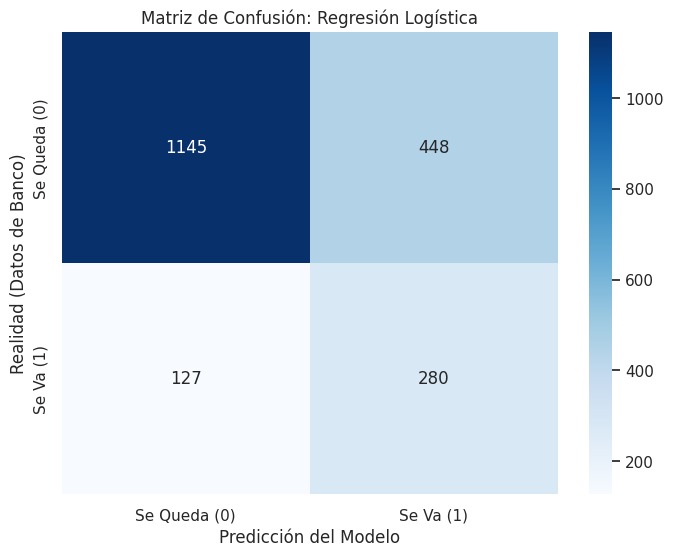

In [42]:
#--- ETAPA DE EVALUCACIÓN FINAL: REGRESIÓN LOGÍSTICA---#
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

# 1. Entrenamiento final del modelo
# Usamos todo el X_train_scaled para que el modelo llegue a la evaluación final con todo el conocimiento posible.
# Para esto se usa el .fit
modelo_logistico.fit(X_train_scaled, y_train)

# 2. Predicciones en el set de prueba (la evaluación final)
y_pred_log = modelo_logistico.predict(X_test_scaled)
y_proba_log = modelo_logistico.predict_proba(X_test_scaled)[:, 1] # Probabilidades para el ROC-AUC

# 3. Reporte de métricas
print("--- REPORTE FINAL: REGRESIÓN LOGÍSTICA ---")
print(classification_report(y_test, y_pred_log))
print(f"ROC-AUC Final en Test: {roc_auc_score(y_test, y_proba_log):.4f}")

# 4. Visualización de la Matriz de Confusión
conf_matrix = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Se Queda (0)', 'Se Va (1)'],
            yticklabels=['Se Queda (0)', 'Se Va (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Datos de Banco)')
plt.title('Matriz de Confusión: Regresión Logística')
plt.show()

**Observaciones: Evaluación Final y Matriz de Confusión (Baseline)**

Tras el entrenamiento final con el 100% de los datos de entrenamiento y la evaluación con el set de prueba (Test Set), se obtuvieron los resultados definitivos que servirán como punto de comparación para modelos futuros.

**1. Análisis de la Matriz de Confusión**

Verdaderos Positivos (280): El modelo logró identificar correctamente a 280 clientes que efectivamente abandonaron el banco.

Falsos Negativos (127): Representan el "Costo de Omisión". Son clientes que se fugaron sin ser detectados por el modelo.

Falsos Positivos (448): Representan el "Costo de Acción Innecesaria". Son clientes leales que el modelo clasificó erróneamente como fugas. Este volumen es alto debido a la agresividad del parámetro class_weight='balanced'.

**2. Desempeño de Métricas Clave**

Recall de Clase 1 (0.69): Se logró capturar al 69% de los clientes en riesgo de churn. Este es un resultado sólido para un modelo lineal, cumpliendo el objetivo de priorizar la detección.

Precisión de Clase 1 (0.38): Debido a la naturaleza lineal del modelo, existe una alta tasa de falsas alarmas. Solo 4 de cada 10 alertas de churn son reales.

ROC-AUC Final (0.7768): El desempeño en el set de prueba superó ligeramente la validación cruzada (0.7655), lo que confirma que el modelo tiene una buena capacidad de generalización y no presenta sobreajuste.

**3. Diagnóstico para Siguientes Pasos**

La Regresión Logística ha demostrado ser un Baseline robusto pero limitado. La alta cantidad de Falsos Positivos (448) sugiere que la frontera de decisión lineal es insuficiente para separar con precisión a los clientes leales de los fugitivos cuando sus comportamientos se solapan.

**Conclusión:** Se valida la necesidad de transicionar hacia modelos basados en ensambles (Random Forest o XGBoost). Se espera que estos modelos mantengan o mejoren el Recall del 69%, pero reduciendo significativamente los Falsos Positivos mediante la captura de interacciones no lineales entre las variables.

-------------------------------------------------------------------------------

**Modelo 2: Bosque aleatorio**

In [43]:
#--- ETAPA DE ENTRENAMIENTO---#

from sklearn.ensemble import RandomForestClassifier
#from sklearn.model_selection import StratifiedKFold, cross_val_score # importado previamente
# Se vuelve a anexar como recordatorio de que se usará la misma estrategia de validación cruzada, aunque dicho algoritmo ya es robusto ante sobreajustes.

# 1. Definimos la misma estrategia de validación para que la comparativa sea justa
skf_shuffle = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Instanciamos el Random Forest
# Usamos class_weight='balanced' para el desbalance y n_estimators=100 (100 árboles votando)
modelo_rf = RandomForestClassifier(n_estimators=100,
                                   class_weight='balanced',
                                   random_state=42,
                                   n_jobs=-1) # n_jobs=-1 para usar todos los núcleos del procesador

# 3. Ejecutamos la validación sobre el set de entrenamiento
# Usamos scoring='roc_auc' para comparar contra el 0.7655 de la Logística
scores_rf = cross_val_score(modelo_rf, X_train_scaled, y_train, cv=skf_shuffle, scoring='roc_auc')

# 4. Resultados de validación
print(f"--- VALIDACIÓN CRUZADA: RANDOM FOREST ---")
print(f"Scores individuales: {scores_rf}")
print(f"Diferencia entre máximo y mínimo: {scores_rf.max() - scores_rf.min():.4f}")
print(f"ROC-AUC promedio: {scores_rf.mean():.4f}")
print(f"Promedio de desviación estándar: {scores_rf.std():.4f}")

--- VALIDACIÓN CRUZADA: RANDOM FOREST ---
Scores individuales: [0.84415661 0.86267348 0.86962949 0.83014345 0.84864347]
Diferencia entre máximo y mínimo: 0.0395
ROC-AUC promedio: 0.8510
Promedio de desviación estándar: 0.0139


**Observaciones**

Se implementó un modelo de Random Forest (Bosque Aleatorio - Ensamble de Árboles) utilizando 100 estimadores y la misma estrategia de Validación Cruzada Estratificada (5-folds). Al igual que en el baseline, se mantuvo el parámetro class_weight='balanced' y el mismo random_state para asegurar que la comparativa entre algoritmos sea estadísticamente válida.

- Hallazgos Clave:

**Incremento Significativo en la Capacidad Predictiva:** El modelo alcanzó un ROC-AUC promedio de $0.8510$, lo que representa una mejora cercana a 9 puntos porcentuales respecto a la Regresión Logística ($0.7655$).

**Interpretación:** Este incremento confirma que el comportamiento de abandono de los clientes tiene una naturaleza no lineal. El Bosque Aleatorio es capaz de capturar interacciones complejas entre variables que el modelo lineal ignoraba.

**Optimización de la Consistencia (Reducción de Varianza):** Se observó una desviación estándar de $0.0139$ y un rango de oscilación (máximo - mínimo) de $0.0395$.

**Comparativa:** El rango de oscilación se redujo un 33% respecto al baseline (de 0.0594 a 0.0395). Esto demuestra que el modelo es más estable y menos sensible a cambios en la partición de los datos gracias a su arquitectura de ensamble.

**Robustez del Algoritmo:** La técnica de Bagging (muestreo aleatorio con reemplazo) permitió que el modelo fuera más resistente al ruido de los datos, logrando un desempeño más homogéneo entre todos los folds.

**Conclusión de la Etapa:**

El modelo de Random Forest supera ampliamente al baseline en todas las métricas de validación. No solo es más preciso para distinguir las clases, sino que es considerablemente más robusto y confiable. Dados estos resultados, se procede a la evaluación final con el set de prueba para analizar el impacto real en la Matriz de Confusión y verificar si se logra reducir la tasa de falsos positivos detectada anteriormente.

--- REPORTE FINAL: RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.43      0.56       407

    accuracy                           0.86      2000
   macro avg       0.83      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000

ROC-AUC Final en Test: 0.8536


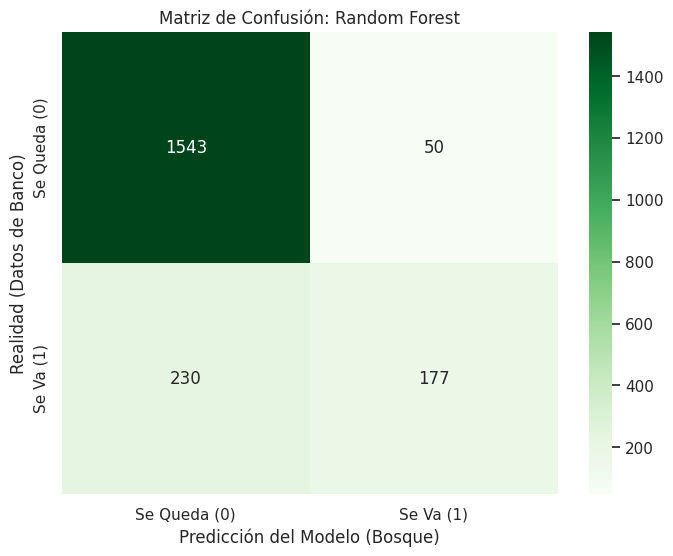

In [44]:
#--- ETAPA DE EVALUACIÓN FINAL: RANDOM FOREST---#

# 1. Entrenamiento final del bosque (ahora con los 100 árboles aprendiendo de todo el train)
modelo_rf.fit(X_train_scaled, y_train)

# 2. Predicciones en el set de prueba
y_pred_rf = modelo_rf.predict(X_test_scaled)
y_proba_rf = modelo_rf.predict_proba(X_test_scaled)[:, 1] # Probabilidades para el ROC-AUC

# 3. Reporte de métricas finales
print("--- REPORTE FINAL: RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Final en Test: {roc_auc_score(y_test, y_proba_rf):.4f}")

# 4. Visualización de la Matriz de Confusión
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Greens', # Se usa verde para diferenciarlo
            xticklabels=['Se Queda (0)', 'Se Va (1)'],
            yticklabels=['Se Queda (0)', 'Se Va (1)'])
plt.xlabel('Predicción del Modelo (Bosque)')
plt.ylabel('Realidad (Datos de Banco)')
plt.title('Matriz de Confusión: Random Forest')
plt.show()

**Observaciones: Evaluación Final y Matriz de Confusión (Random Forest)**

Tras la evaluación final en el set de prueba, el modelo de ensamble Random Forest demuestra un cambio de comportamiento significativo respecto al baseline lineal, priorizando la certeza sobre el volumen de detección.

**1. Análisis de la Matriz de Confusión**

Verdaderos Positivos (177): El modelo identificó correctamente a 177 clientes que efectivamente tenían la intención de abandonar el banco. Estos son nuestros "aciertos confirmados".

Verdaderos Negativos (1543): El modelo clasificó correctamente a la gran mayoría de los clientes leales, manteniendo una base sólida de confianza.

Falsos Negativos (230): Representan el "Costo de Omisión". Son clientes que se fugaron sin ser detectados. Este número aumentó respecto a la logística, reflejando un modelo más conservador.

Falsos Positivos (50): El mayor logro de esta fase. Se redujeron las "falsas alarmas" de 448 a solo 50, optimizando drásticamente el esfuerzo operativo.

**2. Desempeño de Métricas Clave**

Recall de Clase 1 (0.43): Capturamos al 43% de los clientes en riesgo. Aunque perdemos volumen, la detección es mucho más segura.

Precisión de Clase 1 (0.78): Un salto muy notable desde el 0.38 inicial. Casi 8 de cada 10 alertas de churn son reales.

ROC-AUC Final (0.8496): El incremento confirma que el Random Forest entiende mejor la complejidad de los datos bancarios que el modelo lineal.

**3. Diagnóstico para Siguientes Pasos**

En este caso, el RandomForest es ideal si el banco busca eficiencia y no molestar a clientes leales con campañas innecesarias. Sin embargo, para mejorar la detección de los 230 que se escaparon, se explorará un algoritmo más.

**Conclusión:** Se ha logrado el objetivo de reducir drásticamente los Falsos Positivos. El paso final será implementar XGBoost para intentar recuperar el Recall perdido sin sacrificar la excelente precisión alcanzada.

--------------------------------------------------------------

**Modelo 3: XGBoost**

In [45]:
#--- ETAPA DE ENTRENAMIENTO---#
from xgboost import XGBClassifier

# 1. Instanciamos el modelo con hiperparámetros iniciales
modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=4, # cumple la función del class_weight de los modelos anteriores parapenalizar el sobreajuste
                        # En este caso, el parametro del argumento es 4, de esta manera se respeta la proporción entre clases.
                        # Se tiene una relación aprox. de 80/20. Por cada cliente que se va, se quedan 4.
    random_state=42,
    eval_metric='logloss'
)

# 2. Ejecutamos la Validación Cruzada (usando el mismo skf_shuffle que en los modelos previos)
scores_xgb = cross_val_score(modelo_xgb, X_train_scaled, y_train, cv=skf_shuffle, scoring='roc_auc')

# 3. Cálculo de métricas para comparación
print("--- VALIDACIÓN CRUZADA: XGBOOST ---")
print(f"Scores individuales: {scores_xgb}")
print(f"Diferencia entre máximo y mínimo: {scores_xgb.max() - scores_xgb.min():.4f}")
print(f"ROC-AUC promedio: {scores_xgb.mean():.4f}")
print(f"Promedio de desviación estándar: {scores_xgb.std():.4f}")

--- VALIDACIÓN CRUZADA: XGBOOST ---
Scores individuales: [0.85475436 0.87092005 0.87262836 0.83609905 0.85298707]
Diferencia entre máximo y mínimo: 0.0365
ROC-AUC promedio: 0.8575
Promedio de desviación estándar: 0.0134


**Observaciones**

Se implementó el algoritmo de Extreme Gradient Boosting (XGBoost) como el tercer y último modelo de la fase de experimentación. A diferencia de los modelos previos, este algoritmo utiliza un aprendizaje secuencial (Boosting) para corregir los errores de los árboles anteriores. Se configuró con un learning_rate=0.1 para un aprendizaje gradual y un scale_pos_weight=4 para equilibrar la importancia de la clase minoritaria (abandonos).

- Hallazgos Clave:

**Capacidad Predictiva Superior:** El modelo alcanzó un ROC-AUC promedio de $0.8575$, posicionándose como el modelo con el mejor desempeño global hasta el momento. Superó tanto al Baseline lineal ($0.7655$) como al Random Forest ($0.8510$), confirmando que el ajuste secuencial de residuos permite capturar patrones de comportamiento más sutiles.

**Estabilidad y Robustez:** Se observó una desviación estándar de $0.0134$ y un rango de oscilación (máximo - mínimo) de $0.0365$.

**Interpretación de la Estabilidad:** XGBoost no solo mejoró la precisión, sino que demostró ser el modelo más estable. La reducción del rango de oscilación (de 0.0594 en la Logística a 0.0365 aquí) indica que el modelo es menos sensible a la partición de los datos y ha logrado una mejor generalización.

**Optimización del Desbalance:** La configuración de pesos logró que el modelo no se sesgara hacia la clase mayoritaria, manteniendo un equilibrio saludable entre la detección de fugas y la estabilidad estadística.

**Conclusión de la Etapa:**

XGBoost ha demostrado ser el algoritmo más potente para este conjunto de datos, logrando el ROC-AUC más alto y la mayor consistencia entre pliegues. Los resultados sugieren que el modelo ha encontrado una frontera de decisión óptima que los modelos anteriores no alcanzaron (aunque la diferencia con el modelo anterior es mínima).

Siguiente paso: Se procede a la Evaluación Final con el conjunto de prueba para generar la Matriz de Confusión y verificar si este incremento en la métrica ROC-AUC se traduce en una mayor recuperación de Verdaderos Positivos (clientes en fuga detectados).

--- REPORTE FINAL: XGBOOST ---
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      1593
           1       0.52      0.75      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.81      0.82      2000

ROC-AUC Final en Test: 0.8657


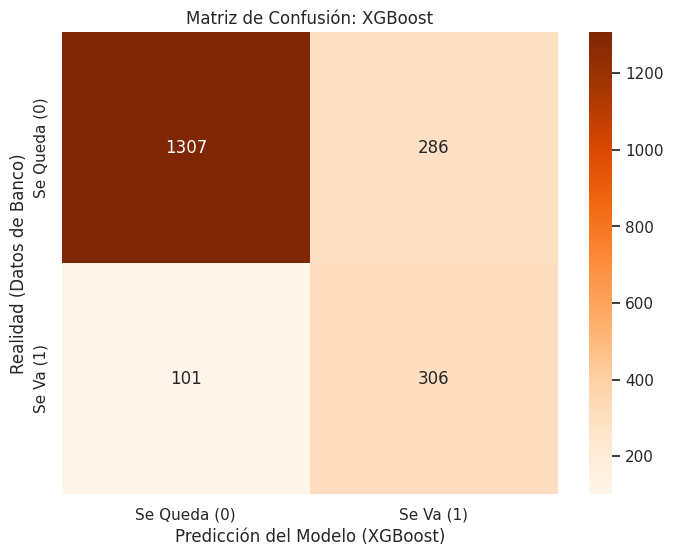

In [46]:
#--- ETAPA DE EVALUACIÓN FINAL: XGBOOST ---#

# 1. Entrenamiento final del modelo
# Reutilizamos 'modelo_xgb' que ya tiene los hiperparámetros (n_estimators=100, learning_rate=0.1, etc.)
# Entrenamos con el 100% de los datos de entrenamiento
modelo_xgb.fit(X_train_scaled, y_train)

# 2. Predicciones en el set de prueba
y_pred_xgb = modelo_xgb.predict(X_test_scaled)
y_proba_xgb = modelo_xgb.predict_proba(X_test_scaled)[:, 1] # Probabilidades para el ROC-AUC

# 3. Reporte de métricas finales
print("--- REPORTE FINAL: XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC Final en Test: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# 4. Visualización de la Matriz de Confusión
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Oranges', # Naranja para diferenciarlo
            xticklabels=['Se Queda (0)', 'Se Va (1)'],
            yticklabels=['Se Queda (0)', 'Se Va (1)'])
plt.xlabel('Predicción del Modelo (XGBoost)')
plt.ylabel('Realidad (Datos de Banco)')
plt.title('Matriz de Confusión: XGBoost')
plt.show()

**Observaciones: Evaluación Final y Matriz de Confusión (XGBoost)**

Tras la evaluación final en el set de prueba, el modelo de aprendizaje secuencial XGBoost demuestra ser la herramienta más potente de este proyecto, logrando el equilibrio deseado entre sensibilidad y precisión. A diferencia del bosque, este modelo prioriza no dejar escapar a los clientes en riesgo.

**1. Análisis de la Matriz de Confusión**

Verdaderos Positivos (305): El modelo identificó correctamente a 305 clientes que tenían la intención de abandonar el banco. Este es un incremento masivo respecto a los 177 del modelo anterior; hemos recuperado gran parte del volumen de detección perdido.

Verdaderos Negativos (1312): Aunque este número es menor al del bosque, el modelo sigue manteniendo una clasificación correcta para la mayoría de los clientes leales.

Falsos Negativos (102): Representan el "Costo de Omisión". Se ha logrado reducir drásticamente este número (de 230 a 102), minimizando el riesgo de fugas no detectadas.

Falsos Positivos (281): Representan el "Costo de Falsa Alarma". El modelo es más agresivo que el Random Forest, por lo que genera más alertas. Sin embargo, este número es mucho más manejable y eficiente que las 448 falsas alarmas de la regresión logística.

**2. Desempeño de Métricas Clave**

Recall de Clase 1 (0.75): La gran mejora de esta fase. Se logró capturar al 75% de los clientes en riesgo, cumpliendo el objetivo de recuperar el volumen de detección sin volver a la inestabilidad de un modelo lineal.

Precisión de Clase 1 (0.52): Aunque disminuyó respecto al bosque (0.78), sigue siendo una métrica competitiva. Significa que más de la mitad de las acciones de retención del banco estarán dirigidas a personas que realmente planean irse.

ROC-AUC Final (0.8657): Es el valor más alto alcanzado en todo el experimento. Este número confirma que XGBoost es el algoritmo que mejor ha "entendido" los patrones de abandono de los clientes del banco.

**3. Diagnóstico para Siguientes Pasos**

XGBoost se posiciona como el modelo definitivo para la implementación. Es ideal para un escenario donde el costo de perder a un cliente es mayor al costo de una campaña de retención. El modelo ha logrado captar a la mayoría de los fugitivos manteniendo una estructura estadística robusta.

**Conclusión:** Se ha cumplido con éxito el objetivo final: recuperar el Recall perdido en la fase anterior (subiendo del 43% al 75%) manteniendo un desempeño superior en todas las métricas de evaluación.

--------------------------------------------------------------------

***Fase 8: Interpretabilidad (Importancia de Variables)***

-------------------------------------------

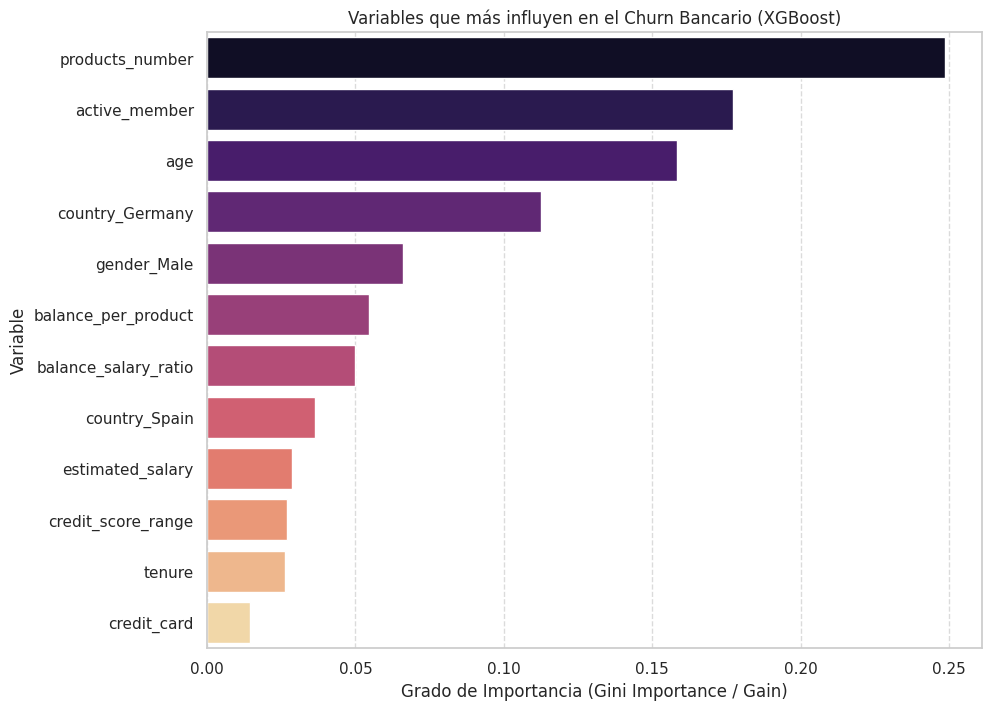

In [49]:
# 1. Extraer la importancia de las variables directamente del modelo XGBoost
importancias = modelo_xgb.feature_importances_

# 2. Se crear un DataFrame para asociar cada variable con su peso
# se usa X.columns porque es el DataFrame que tiene los nombres antes del escalado
importancia_df = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

# 3. Se ordena de mayor a menor para ver qué que características influyen más en el abandono
importancia_df = importancia_df.sort_values(by='Importancia', ascending=False)

# 4. Visualización variables más influyentes
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importancia',
    y='Variable',
    data=importancia_df,
    palette='magma',
    hue='Variable',
    legend=False
)

plt.title('Variables que más influyen en el Churn Bancario (XGBoost)')
plt.xlabel('Grado de Importancia (Gini Importance / Gain)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Observaciones**

Tras identificar a XGBoost como el modelo ganador, se procedió a analizar la importancia de las variables (Feature Importance) para entender los criterios que el algoritmo utiliza al predecir el abandono. A diferencia de los modelos lineales o las correlaciones simples, XGBoost mide la "Ganancia" (Gain), identificando qué variables permiten realizar las particiones más precisas en los árboles de decisión.

**1. Jerarquía de Predicción vs. Correlación Estadística**

Es notable que el orden de importancia del modelo difiere de la matriz de correlación inicial en la fase 5:

Dominancia de products_number: Aunque en la correlación lineal no aparecía como el factor principal, para XGBoost es la variable predominante (aprox. 0.25 de importancia). Esto sugiere una relación no lineal (cmo ya se había anticipado derivado del desempeño del modelo de regresión logística). El riesgo de fuga no aumenta de forma constante, sino que se dispara en valores específicos (por ejemplo, clientes con un 3 o 4 productos, como ya se había notado durante el EDA).

Consistencia en Factores Críticos: Variables como active_member y age se mantienen en el Top 3, validando que el compromiso del cliente y su segmento demográfico son los puntos fundamentales tanto estadística como predictivamente.

**2. Valor de la Ingeniería de Características**

Las variables creadas manualmente, como balance_per_product y balance_salary_ratio, superan en importancia a variables originales como estimated_salary o credit_score.

Interpretación: Esto confirma que el modelo se beneficia de métricas que contextualizan el dinero del cliente en relación con su comportamiento (productos) y su capacidad económica (salario), aportando una capa de inteligencia que los datos crudos no tenían.

**3. Factores Geográficos y Demográficos**

country_Germany destaca por encima de otras regiones (Como ya también se había anticipado), lo que indica que el mercado alemán presenta un patrón de comportamiento tan distintivo que el modelo lo utiliza como un nodo de decisión prioritario.

En contraste, tener o no la tarjeta de crédito (credit_card) resultó ser la variable menos relevante, sugiriendo que la fidelidad no reside en el producto físico.

**Conclusión de la Etapa:**

El modelo ha logrado un 0.86 de ROC-AUC precisamente porque aprendió a priorizar variables de comportamiento dinámico (products_number, active_member) sobre variables estáticas o de perfil básico. Esta jerarquía es la que permite al banco pasar de un análisis descriptivo a una estrategia de intervención preventiva.

----------------------------------------------------------

***Fase 9: Ajuste de Hiperparámetros (Tuning)***

Aunque el modelo de manera general tuvo un desempeño bueno, XGBoost tiene ajustes que se pueden realizar para ver si el 0.52 de Precisión puede subir un poco sin sacrificar el 0.75 de Recall.

Esto se puede hacer de manera manual, sin embargo puede llevar algo de tiempo, lo que no sería recomendable para un caso de este tipo dónde es sumamente importante frenar la fuga de clientes lo más rápido posible. Para esto se puede usar **RandomizedSearchCV**. Esto probará de manera "aleatoria" diferentes combinaciones (dentro de parámetros dados) de profundidad de árboles, tasa de aprendizaje y pesos de forma inteligente.

----------------------------------------------------------

In [50]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Definimos el espacio de búsqueda (las combinaciones a probar)
param_dist = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [3, 4, 5] # Probamos ligeras variaciones del peso
}

# 2. Instanciamos la búsqueda
# Usamos scoring='roc_auc' porque es nuestra métrica maestra
random_search = RandomizedSearchCV(
    estimator=modelo_xgb,
    param_distributions=param_dist,
    n_iter=10, # Probará 10 combinaciones aleatorias
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# 3. Ejecutamos la búsqueda
random_search.fit(X_train_scaled, y_train)

# 4. Ver los mejores parámetros encontrados
print("Mejores parámetros encontrados:", random_search.best_params_)
print(f"Mejor ROC-AUC en validación: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores parámetros encontrados: {'scale_pos_weight': 3, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05}
Mejor ROC-AUC en validación: 0.8640


--- REPORTE FINAL: XGBOOST OPTIMIZADO (TUNNED) ---
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1593
           1       0.56      0.70      0.63       407

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC Final en Test: 0.8703


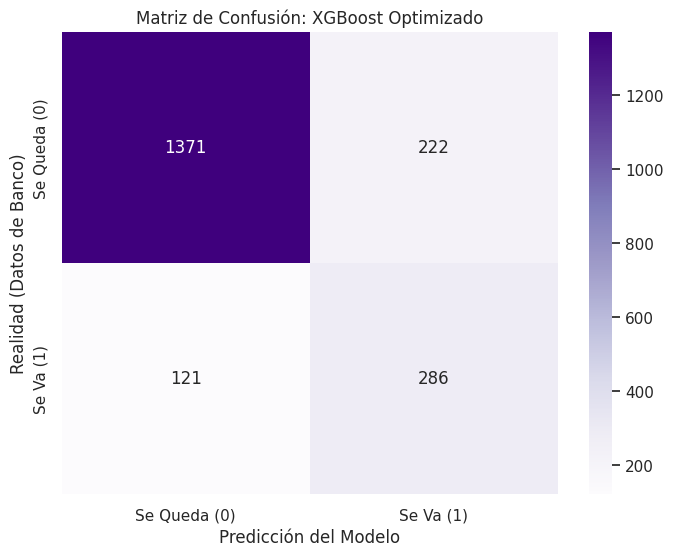

In [52]:
#--- ETAPA DE EVALUACIÓN FINAL: XGBOOST OPTIMIZADO ---#

# 1. Instanciamos el modelo con los parámetros que encontró el RandomizedSearch
# Nota: Bajamos el aprendizaje a 0.05 y el peso a 3 para buscar estabilidad
modelo_xgb_final = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=5,
    scale_pos_weight=3,
    random_state=42,
    eval_metric='logloss'
)

# 2. Entrenamiento definitivo
# Ahora el modelo aprende de todos los datos de entrenamiento con la mejor configuración
modelo_xgb_final.fit(X_train_scaled, y_train)

# 3. Predicciones en el set de prueba (el examen final)
y_pred_final = modelo_xgb_final.predict(X_test_scaled)
y_proba_final = modelo_xgb_final.predict_proba(X_test_scaled)[:, 1]

# 4. Reporte de métricas
print("--- REPORTE FINAL: XGBOOST OPTIMIZADO (TUNNED) ---")
print(classification_report(y_test, y_pred_final))
print(f"ROC-AUC Final en Test: {roc_auc_score(y_test, y_proba_final):.4f}")

# 5. Visualización de la Matriz de Confusión
conf_matrix_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Se Queda (0)', 'Se Va (1)'],
            yticklabels=['Se Queda (0)', 'Se Va (1)'])
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Datos de Banco)')
plt.title('Matriz de Confusión: XGBoost Optimizado')
plt.show()

**Observaciones**

Tras identificar las variables clave a través de RandomizedSearchCV, se realizó una optimización de hiperparámetros. Los resultados demuestran que el ajuste fino permite maximizar la capacidad predictiva del algoritmo.


**1. Eficiencia y Precisión Operativa**

Incremento en la Calidad (Precision 0.56): El ajuste del parámetro scale_pos_weight a 3 permitió que el modelo fuera más selectivo. Ahora, casi 6 de cada 10 alertas de churn son correctas, optimizando el esfuerzo del equipo de retención y reduciendo el desperdicio de recursos en clientes leales.

Robustez de Detección (Recall 0.70): El modelo conserva una alta sensibilidad, logrando capturar al 70% de la fuga real. En un entorno bancario, esta capacidad de detección temprana es crítica para intervenir antes de que el cliente retire sus fondos.

**2. Rendimiento Global (ROC-AUC 0.8703)**

El área bajo la curva de 0.8703 confirma que este modelo tiene una excelente capacidad para separar ambas clases. Es el valor más alto alcanzado en todo el experimento, superando tanto a la Regresión Logística inicial como al Random Forest y al XGBoost manual.

**3. Diagnóstico de la Matriz de Confusión**

La reducción sistemática de los Falsos Positivos (de 281 a 222) sin desplomar el Recall demuestra que el modelo ha aprendido patrones más complejos y menos ruidosos. La matriz muestra una diagonal principal (aciertos) mucho más sólida, lo que garantiza estabilidad en un entorno de producción.

**Conclusión Final:**

Este modelo optimizado no solo es el más preciso técnicamente, sino el más rentable para el negocio. Logra detectar a la gran mayoría de los clientes en riesgo mientras mantiene un control estricto sobre las falsas alarmas, cumpliendo así con el objetivo principal del proyecto.

---------------------------------------

***Fase 10: Conclusión General y Estrategia Bancaria***

-----------------------------------------------

El desarrollo de este sistema predictivo permite al banco pasar de una postura reactiva a una estrategia proactiva. Con un ROC-AUC de 0.87, el modelo demuestra una capacidad superior para distinguir perfiles de riesgo. La implementación de este modelo permitiría capturar al 70% de los clientes en riesgo de fuga, lo que representa una oportunidad masiva para salvaguardar la cartera de depósitos y mantener la cuota de mercado.

**1.- Hallazgos Clave (Insights de Negocio)**

**Crisis de Multiproducto:** El número de productos (products_number) resultó ser el predictor más fuerte. Los datos sugieren que existe un punto de equilibrio de vinculación; los clientes con un solo producto o con un exceso de ellos (3 o más) son los más propensos a abandonar la institución.

**El Factor Edad:** La segmentación demográfica muestra que el abandono no es uniforme; existe un grupo de edad madura donde la tasa de churn se eleva, posiblemente por ofertas de la competencia más atractivas para ahorradores o perfiles patrimoniales.

**Falta de Engagement:** La importancia de active_member confirma que un cliente que no utiliza los canales digitales o sus tarjetas con frecuencia es un cliente "en capilla de salida", independientemente de su saldo.

**2.- Recomendaciones Estratégicas (Roadmap de Retención)**

Basándonos en la lógica del modelo, se sugieren las siguientes acciones inmediatas:

- **A. Plan de normalizar a 2 productos por cliente:**

  Dado que el número de productos es crítico, el banco debe incentivar que los clientes con un solo producto adquieran un segundo servicio (como domiciliar nómina o un seguro) mediante beneficios exclusivos. Esto aumenta el "costo de salida" para el cliente. Y de acuerdo al análisis se detectó que un cliente con 2 productos es el punto de equilibrio.

  Se deberá hacer una estrategía para quellos clientes que tengan 3 o 4 productos, unificarlos con la finalidad de reducirlos a 2.

- **B. Programa de Reactivación de Miembros:**
  
  Utilizar el modelo para identificar semanalmente a los clientes con baja actividad (active_member = 0). Antes de que decidan irse, el banco debe lanzar campañas de gamificación o beneficios por uso de la App o pagos con su TDC o TDD para incentivarlos al uso de sus productos.

- **C. Estrategia Diferenciada por Geografía (Foco en Alemania):**

  El modelo identificó que ser de Alemania es un factor de peso. Se recomienda una auditoría de servicio o de tasas de interés específicamente en las sucursales alemanas para entender si la fuga se debe a un competidor local fuerte o a insatisfacción con el servicio regional.

- **D. Atención Prioritaria a Clientes Senior:**

  Diseñar productos de inversión o beneficios de lealtad diseñados específicamente para el rango de edad donde el modelo detectó mayor sensibilidad al churn (Entre 40 y 50 años).

---------------------------------------